# De Novo Lead-Binding Protein Design — RFD3 Pipeline

```text
RFD3  →  ProteinMPNN  →  RF3
```

This notebook is adapted for the **lead-sensing project** using the Pb²⁺-Cys₃ motif from **PbrR691 / 5GPE**.

Important correction compared with the generic binder-design notebook:

- `radius` is used for **motif inspection / chemical justification**.
- `target-window` / `contig` is what RFD3 actually receives as fixed structural context.
- `select_fixed_atoms` preserves the Pb-coordinating Cys atoms.
- `ori_token` controls where the new scaffold is placed relative to the Pb site.

The notebook does **not** rebuild the motif scan. It consumes the JSON inputs already produced by:

```bash
bsub < 01_prepare_rfd3_inputs.sh
```

## How to run

1. Run `01_prepare_rfd3_inputs.sh` first.
2. Open this notebook from the project root or from `scripts/`.
3. Set `PREP_EXPERIMENT` below to the folder containing your prepared RFD3 inputs, for example `exp_01` or `exp_02`.
4. Run cells top to bottom.

GPU stages write LSF scripts and print the `bsub < ...` command. Submit those commands in a terminal, wait for the jobs to finish, then continue.

## 0. Setup: imports, repo paths, run configuration

In [39]:
# --- Core ---
import os
import re
import csv
import glob
import json
import math
import gzip
import shutil
from pathlib import Path
from copy import deepcopy

# --- Data / plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

def find_repo_root(start: Path) -> Path:
    """Find the lead_sensoring project root from the current notebook directory."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        has_structure = (candidate / "data" / "raw" / "5gpe.cif").exists()
        has_scripts = (candidate / "scripts").is_dir()
        if has_structure and has_scripts:
            return candidate
    raise RuntimeError(
        f"Could not find the project root from {start}. "
        "Run this notebook from the lead_sensoring root or from lead_sensoring/scripts."
    )

REPO_ROOT = find_repo_root(Path.cwd())
STRUCTURE_CIF = (REPO_ROOT / "data" / "raw" / "5gpe.cif").resolve()

# Helper module path for project-specific scripts, if needed.
sys_path_candidate = REPO_ROOT / "scripts" / "lib"
if str(sys_path_candidate) not in os.sys.path:
    os.sys.path.insert(0, str(sys_path_candidate))

print("Repo root :", REPO_ROOT)
print("5GPE CIF  :", STRUCTURE_CIF)
print("User      :", os.environ.get("USER", "?"))

Repo root : /dtu/blackhole/00/222976/lead_sensoring
5GPE CIF  : /dtu/blackhole/00/222976/lead_sensoring/data/raw/5gpe.cif
User      : s252608


In [ ]:
# -------------------------------------------------------------------------
# User-editable configuration
# -------------------------------------------------------------------------

# This is the experiment produced by 01_prepare_rfd3_inputs.sh.
# From your tree, exp_01 and exp_02 both exist. Use the one you want to run.
PREP_EXPERIMENT = "exp_02"

# This is the downstream RFD3/MPNN/RF3 run folder created by this notebook.
RUN_EXPERIMENT = f"{PREP_EXPERIMENT}_rfd3_mpnn_rf3"

# LSF / environment settings.
QUEUE = "c27666"
CONDA_SH = "/dtu/projects/dbl/foundry/miniforge3/etc/profile.d/conda.sh"

# Use the environment where the commands `rfd3` and `mpnn` are available.
# Change these if your cluster installation uses a different environment.
RFD3_CONDA_ENV = "rfd3"
MPNN_CONDA_ENV = "rfd3"

# RFD3 checkpoint. Change if your local RFD3 weights live elsewhere.
RFD3_CKPT_PATH = "/dtu/blackhole/00/c27666/27666_Protein_Design/weights/rfd3_latest.ckpt"

# ProteinMPNN checkpoint. Change if needed.
PROTEINMPNN_CKPT = "/dtu/blackhole/00/c27666/27666_Protein_Design/weights/proteinmpnn_v_48_020.pt"

# RF3 settings.
RF3_RELEASE = "/dtu/projects/dbl/rf3/release"
RF3_CKPT_PATH = "/dtu/blackhole/00/c27666/27666_Protein_Design/weights/rf3_foundry_01_24_latest_remapped.ckpt"
RF3_NUM_STEPS = 50

# SpyTag appended after MPNN and before RF3 validation.
SPYTAG_LINKER = "GSGSGS"
SPYTAG_SEQ = "AHIVMVDAYKPTK"
SPYTAG = SPYTAG_LINKER + SPYTAG_SEQ

# RFD3 sampling defaults. Keep small while debugging.
DIFFUSION_BATCH_SIZE = 1
N_BATCHES = 4

# ProteinMPNN defaults.
MPNN_SEED = 42
MPNN_BATCH_SIZE = 2
MPNN_NUMBER_OF_BATCHES = 2
CHAINS_TO_DESIGN = "A"

print("Preparation experiment:", PREP_EXPERIMENT)
print("Run experiment        :", RUN_EXPERIMENT)
print("SpyTag                :", SPYTAG, f"({len(SPYTAG)} aa)")

Preparation experiment: exp_01
Run experiment        : exp_01_rfd3_mpnn_rf3
SpyTag                : GSGSGSAHIVMVDAYKPTK (19 aa)


In [3]:
# -------------------------------------------------------------------------
# Working directories
# -------------------------------------------------------------------------

PREP_ROOT = REPO_ROOT / "work" / PREP_EXPERIMENT
if not PREP_ROOT.exists():
    available = sorted(p.name for p in (REPO_ROOT / "work").glob("exp*"))
    raise RuntimeError(
        f"PREP_ROOT does not exist: {PREP_ROOT}\n"
        f"Available work experiments: {available}"
    )

WORK = REPO_ROOT / "work" / RUN_EXPERIMENT

subdirs = [
    "cmds",
    "submit",
    "logs",
    "configs",
    "scores",
    "diffusion_out",
    "mpnn_out",
    "rf3_out",
    "best_binders",
]
for subdir in subdirs:
    (WORK / subdir).mkdir(parents=True, exist_ok=True)

cmds_dir = WORK / "cmds"
submit_dir = WORK / "submit"
logs_dir = WORK / "logs"
configs_dir = WORK / "configs"
scores_dir = WORK / "scores"
diffusion_out_dir = WORK / "diffusion_out"
mpnn_out_dir = WORK / "mpnn_out"
rf3_out_dir = WORK / "rf3_out"
best_binders_dir = WORK / "best_binders"

print("Preparation root:", PREP_ROOT)
print("Working dir     :", WORK)

Preparation root: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01
Working dir     : /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3


## 1. Load prepared RFD3 inputs

This cell discovers the RFD3 input JSONs generated by `1_prepare_rfd3_inputs.py`.

It supports both layouts:

```text
work/exp_02/rfdiffusion_inputs/rfd3_input_*.json
```

and nested window layouts:

```text
work/exp_03/w4/rfdiffusion_inputs/rfd3_input_*.json
work/exp_03/w6/rfdiffusion_inputs/rfd3_input_*.json
```

The old course notebook hard-coded `rfd3_test_1zg4`, `select_hotspots`, and `inputs/1zg4.pdb`. That is removed here.

In [5]:
def load_payload(path: Path) -> tuple[str, dict]:
    """Load one RFD3 input JSON and return its single design name and payload."""
    with path.open() as handle:
        data = json.load(handle)

    if len(data) != 1:
        raise ValueError(f"Expected exactly one design per RFD3 input JSON: {path}")

    design_name = next(iter(data))
    return design_name, data[design_name]


def classify_contig_style(contig: str) -> str:
    """Classify whether the contig is monomeric or binder-style."""
    if "/0" in contig:
        return "binder"
    return "monomeric"


def infer_window_label_from_contig(contig: str) -> str:
    """Infer a rough window label from the Cys78 chain-C segment in the contig."""
    match = re.search(r"C(\d+)-(\d+)", contig)

    if not match:
        return "wNA"

    start, end = map(int, match.groups())

    if start <= 78 <= end:
        window = max(78 - start, end - 78)
        return f"w{window}"

    return "wNA"


def context_for_input_json(input_json: Path) -> Path:
    """Find the context PDB corresponding to one prepared RFD3 input JSON."""
    candidate = input_json.parent.parent / "contexts" / "rfd3_context_fixed_segments_plus_pb.pdb"

    if candidate.exists():
        return candidate.resolve()

    raise FileNotFoundError(
        f"Could not find context PDB for {input_json}. "
        "Expected ../contexts/rfd3_context_fixed_segments_plus_pb.pdb."
    )


def condition_label_from_json(input_json: Path, payload: dict) -> str:
    """Build a stable condition label from window and ORI labels."""
    raw_label = input_json.stem.replace("rfd3_input_", "")
    window_label = infer_window_label_from_contig(payload["contig"])

    if raw_label.startswith("w"):
        return raw_label

    return f"{window_label}_{raw_label}"


def write_runtime_rfd3_json(
    input_json: Path,
    design_name: str,
    payload: dict,
    context_pdb: Path,
    condition: str,
    outdir: Path,
) -> Path:
    """Write a runtime RFD3 JSON using the reduced context PDB as input."""
    outdir.mkdir(parents=True, exist_ok=True)

    runtime_payload = dict(payload)
    runtime_payload["input"] = str(context_pdb.resolve())

    runtime_json = outdir / f"rfd3_input_{condition}.json"

    with runtime_json.open("w") as handle:
        json.dump({design_name: runtime_payload}, handle, indent=2)

    return runtime_json.resolve()


# Discover prepared inputs.
flat_inputs = sorted((PREP_ROOT / "rfdiffusion_inputs").glob("rfd3_input_*.json"))
nested_inputs = sorted(PREP_ROOT.glob("*/rfdiffusion_inputs/rfd3_input_*.json"))
rfd3_input_jsons = sorted(set(flat_inputs + nested_inputs))

if not rfd3_input_jsons:
    raise RuntimeError(f"No RFD3 input JSONs found under {PREP_ROOT}")


runtime_json_dir = configs_dir / "rfd3_runtime_inputs"
manifest_rows = []

for input_json in rfd3_input_jsons:
    design_name, payload = load_payload(input_json)
    context_pdb = context_for_input_json(input_json)
    condition = condition_label_from_json(input_json, payload)

    contig = payload["contig"]
    contig_style = classify_contig_style(contig)

    if contig_style == "monomeric":
        print(f"[OK] Monomeric single-chain motif transplantation contig: {input_json.name}")
        print(f"     contig = {contig}")
    else:
        print(f"[INFO] Binder-style contig detected: {input_json.name}")
        print(f"       contig = {contig}")

    if "select_fixed_atoms" not in payload:
        print(f"[WARNING] Missing select_fixed_atoms in {input_json}")

    if "ori_token" not in payload:
        print(f"[WARNING] Missing ori_token in {input_json}")

    runtime_json = write_runtime_rfd3_json(
        input_json=input_json,
        design_name=design_name,
        payload=payload,
        context_pdb=context_pdb,
        condition=condition,
        outdir=runtime_json_dir,
    )

    manifest_rows.append({
        "condition": condition,
        "source_input_json": str(input_json.resolve()),
        "runtime_input_json": str(runtime_json),
        "context_pdb": str(context_pdb),
        "design_name": design_name,
        "contig": contig,
        "contig_style": contig_style,
        "length": payload.get("length"),
        "original_input": payload.get("input"),
        "runtime_input": str(context_pdb),
        "has_select_fixed_atoms": "select_fixed_atoms" in payload,
        "has_ori_token": "ori_token" in payload,
    })


rfd3_manifest = (
    pd.DataFrame(manifest_rows)
    .sort_values(["condition", "runtime_input_json"])
    .reset_index(drop=True)
)

manifest_csv = configs_dir / "rfd3_input_manifest.csv"
rfd3_manifest.to_csv(manifest_csv, index=False)

print(f"\nFound {len(rfd3_manifest)} prepared RFD3 input JSON(s).")
print(f"Manifest: {manifest_csv}")
print(f"Runtime JSONs: {runtime_json_dir}")

rfd3_manifest

[OK] Monomeric single-chain motif transplantation contig: rfd3_input_scaffold-side-12A.json
     contig = 10-50,C72-84,5-20,D107-128,10-50
[OK] Monomeric single-chain motif transplantation contig: rfd3_input_scaffold-side-15A.json
     contig = 10-50,C72-84,5-20,D107-128,10-50
[OK] Monomeric single-chain motif transplantation contig: rfd3_input_scaffold-side-5A.json
     contig = 10-50,C72-84,5-20,D107-128,10-50
[OK] Monomeric single-chain motif transplantation contig: rfd3_input_scaffold-side-8A.json
     contig = 10-50,C72-84,5-20,D107-128,10-50

Found 4 prepared RFD3 input JSON(s).
Manifest: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/configs/rfd3_input_manifest.csv
Runtime JSONs: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/configs/rfd3_runtime_inputs


,condition,source_input_json,runtime_input_json,context_pdb,design_name,contig,contig_style,length,original_input,runtime_input,has_select_fixed_atoms,has_ori_token
0,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,5gpe_pb_motif_r5_scaffold-side-12A,"10-50,C72-84,5-20,D107-128,10-50",monomeric,60-155,/dtu/blackhole/00/222976/lead_sensoring/data/r...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,True
1,w6_scaffold-side-15A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,5gpe_pb_motif_r5_scaffold-side-15A,"10-50,C72-84,5-20,D107-128,10-50",monomeric,60-155,/dtu/blackhole/00/222976/lead_sensoring/data/r...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,True
2,w6_scaffold-side-5A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,5gpe_pb_motif_r5_scaffold-side-5A,"10-50,C72-84,5-20,D107-128,10-50",monomeric,60-155,/dtu/blackhole/00/222976/lead_sensoring/data/r...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,True
3,w6_scaffold-side-8A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,5gpe_pb_motif_r5_scaffold-side-8A,"10-50,C72-84,5-20,D107-128,10-50",monomeric,60-155,/dtu/blackhole/00/222976/lead_sensoring/data/r...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,True


## 2. RFD3 — generate scaffold backbones

Each prepared JSON is submitted as a separate condition.  
The output directory is condition-specific, so `w4_scaffold-side-8A` and `w6_scaffold-side-12A` do not get mixed.

Expected binder-style contigs look like:

```text
80-140,/0,C74-82,/0,D109-126
80-140,/0,C72-84,/0,D107-128
```

That means:

- chain A: new de novo scaffold
- chain C/D: fixed Pb-Cys₃ context
- Pb²⁺: retained from the input structure/context

In [6]:
def write_lsf_array_script(
    cmds_path: Path,
    script_path: Path,
    job_name: str,
    queue: str,
    cores: int,
    mem: str,
    time_limit: str,
    group_size: int,
    gpu_spec: str | None = None,
    activate_lines: str = "",
    extra_exports: str = "",
) -> Path:
    """Write a generic LSF job-array script that executes commands from a file."""
    n_cmds = sum(1 for _ in cmds_path.open())
    if n_cmds == 0:
        raise RuntimeError(f"No commands in {cmds_path}")

    n_arrays = math.ceil(n_cmds / group_size)
    gpu_line = f'#BSUB -gpu "{gpu_spec}"\n' if gpu_spec else ""

    script = f"""#!/bin/sh
#BSUB -q {queue}
#BSUB -J {job_name}[1-{n_arrays}]
#BSUB -n {cores}
{gpu_line}#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J_%I.out
#BSUB -e {logs_dir}/%J_%I.err

set -eu

mkdir -p {logs_dir}
{activate_lines}
{extra_exports}

CMDS_FILE="{cmds_path}"
GROUP_SIZE={group_size}
START=$(( (LSB_JOBINDEX - 1) * GROUP_SIZE ))
END=$(( START + GROUP_SIZE ))

i=0
while IFS= read -r cmd; do
    if [ "$i" -ge "$START" ] && [ "$i" -lt "$END" ]; then
        echo "Running command index $i"
        echo "$cmd"
        eval "$cmd"
    fi
    i=$((i+1))
done < "$CMDS_FILE"

echo "Done at $(date)"
"""
    script_path.write_text(script)
    return script_path

# RFD3 command file.
rfd3_cmds = cmds_dir / "rfd3.cmds"

with rfd3_cmds.open("w") as handle:
    for _, row in rfd3_manifest.iterrows():
        condition = row["condition"]
        out_dir = diffusion_out_dir / condition
        out_dir.mkdir(parents=True, exist_ok=True)

        cmd = (
            f'rfd3 design '
            f'out_dir="{out_dir}" '
            f'inputs="{row["runtime_input_json"]}" '
            f'ckpt_path="{RFD3_CKPT_PATH}" '
            f'diffusion_batch_size={DIFFUSION_BATCH_SIZE} '
            f'n_batches={N_BATCHES} '
            f'low_memory_mode=True '
            f'inference_sampler.step_scale=3 '
            f'inference_sampler.gamma_0=0.2'
        )
        handle.write(cmd + "\n")

activate_rfd3 = f"""
module load cuda/12.4
source "{CONDA_SH}"
conda activate "{RFD3_CONDA_ENV}"
"""

exports_rfd3 = """
export DISABLE_CUEQUIVARIANCE=true
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
"""

rfd3_script = write_lsf_array_script(
    cmds_path=rfd3_cmds,
    script_path=submit_dir / "rfd3.sh",
    job_name="rfd3_pb",
    queue=QUEUE,
    cores=4,
    mem="10GB",
    time_limit="2:00",
    group_size=1,
    gpu_spec="num=1:mode=exclusive_process",
    activate_lines=activate_rfd3,
    extra_exports=exports_rfd3,
)

print(f"Wrote {rfd3_cmds}")
print(f"Wrote {rfd3_script}")
print(f"Backbones per condition: {DIFFUSION_BATCH_SIZE * N_BATCHES}")
print("\nSubmit:")
print(f"  bsub < {rfd3_script}")

Wrote /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/cmds/rfd3.cmds
Wrote /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/submit/rfd3.sh
Backbones per condition: 20

Submit:
  bsub < /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/submit/rfd3.sh


## 3. Process RFD3 outputs

Run this section after the RFD3 jobs finish.

In [20]:
def matching_structure_for_rfd3_json(json_path: Path) -> Path | None:
    """Find the CIF/CIF.GZ matching one RFD3 metrics JSON."""
    stem = json_path.stem
    candidates = [
        json_path.with_name(stem + ".cif.gz"),
        json_path.with_name(stem + ".cif"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return None

json_paths = sorted(diffusion_out_dir.glob("*/*.json"))
if not json_paths:
    raise SystemExit(f"No RFD3 JSON metrics found under {diffusion_out_dir}. Run RFD3 first.")

rows = []
all_keys = {"condition", "json_path", "structure_path"}

for jp in json_paths:
    with jp.open() as handle:
        data = json.load(handle)

    metrics = data.get("metrics", {})
    condition = jp.parent.name
    structure_path = matching_structure_for_rfd3_json(jp)

    row = {
        "condition": condition,
        "json_path": str(jp.resolve()),
        "structure_path": str(structure_path) if structure_path else "",
    }

    for key, value in metrics.items():
        if key in ("diffused_com", "fixed_com") and isinstance(value, (list, tuple)) and len(value) == 3:
            row[f"{key}_x"], row[f"{key}_y"], row[f"{key}_z"] = value
            all_keys.update({f"{key}_x", f"{key}_y", f"{key}_z"})
        else:
            row[key] = value
            all_keys.add(key)

    rows.append(row)

fieldnames = ["condition", "json_path", "structure_path"] + sorted(k for k in all_keys if k not in {"condition", "json_path", "structure_path"})

rfd3_metrics_csv = scores_dir / "rfd3_metrics_with_json_path.csv"
with rfd3_metrics_csv.open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

df_rfd3 = pd.read_csv(rfd3_metrics_csv)
print(f"Wrote {len(df_rfd3)} rows -> {rfd3_metrics_csv}")
df_rfd3.head()

Wrote 16 rows -> /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/rfd3_metrics_with_json_path.csv


,condition,json_path,structure_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.496454,0.800059,-0.731369,-0.510821,5.113996,9.014856,-2.913921,0.049645,0.811321,0.188679,0.107031,0,0,0,0.811321,141,5,14.099353,0.0
1,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.457143,-0.654161,-0.778662,-3.853013,5.113996,9.014856,-2.913921,0.038095,0.814286,0.185714,0.107031,0,0,0,0.814286,105,6,12.686934,0.0
2,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.408163,0.242436,-1.852085,-7.066871,5.113996,9.014856,-2.913921,0.051020,0.793651,0.206349,0.107031,0,0,0,0.793651,98,5,10.911148,0.0
3,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.469231,1.179567,-1.308523,-1.284929,5.113996,9.014856,-2.913921,0.038462,0.810526,0.189474,0.107031,0,0,0,0.810526,130,7,13.413426,0.0
4,w6_scaffold-side-15A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.472441,-1.088772,2.290252,-1.857908,6.261300,11.585849,-3.948044,0.039370,0.739130,0.260870,0.101812,0,0,1,0.739130,127,6,13.321306,0.0


Plotting: ['alanine_content', 'glycine_content', 'helix_fraction', 'loop_fraction', 'sheet_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'non_loop_fraction', 'radius_of_gyration']


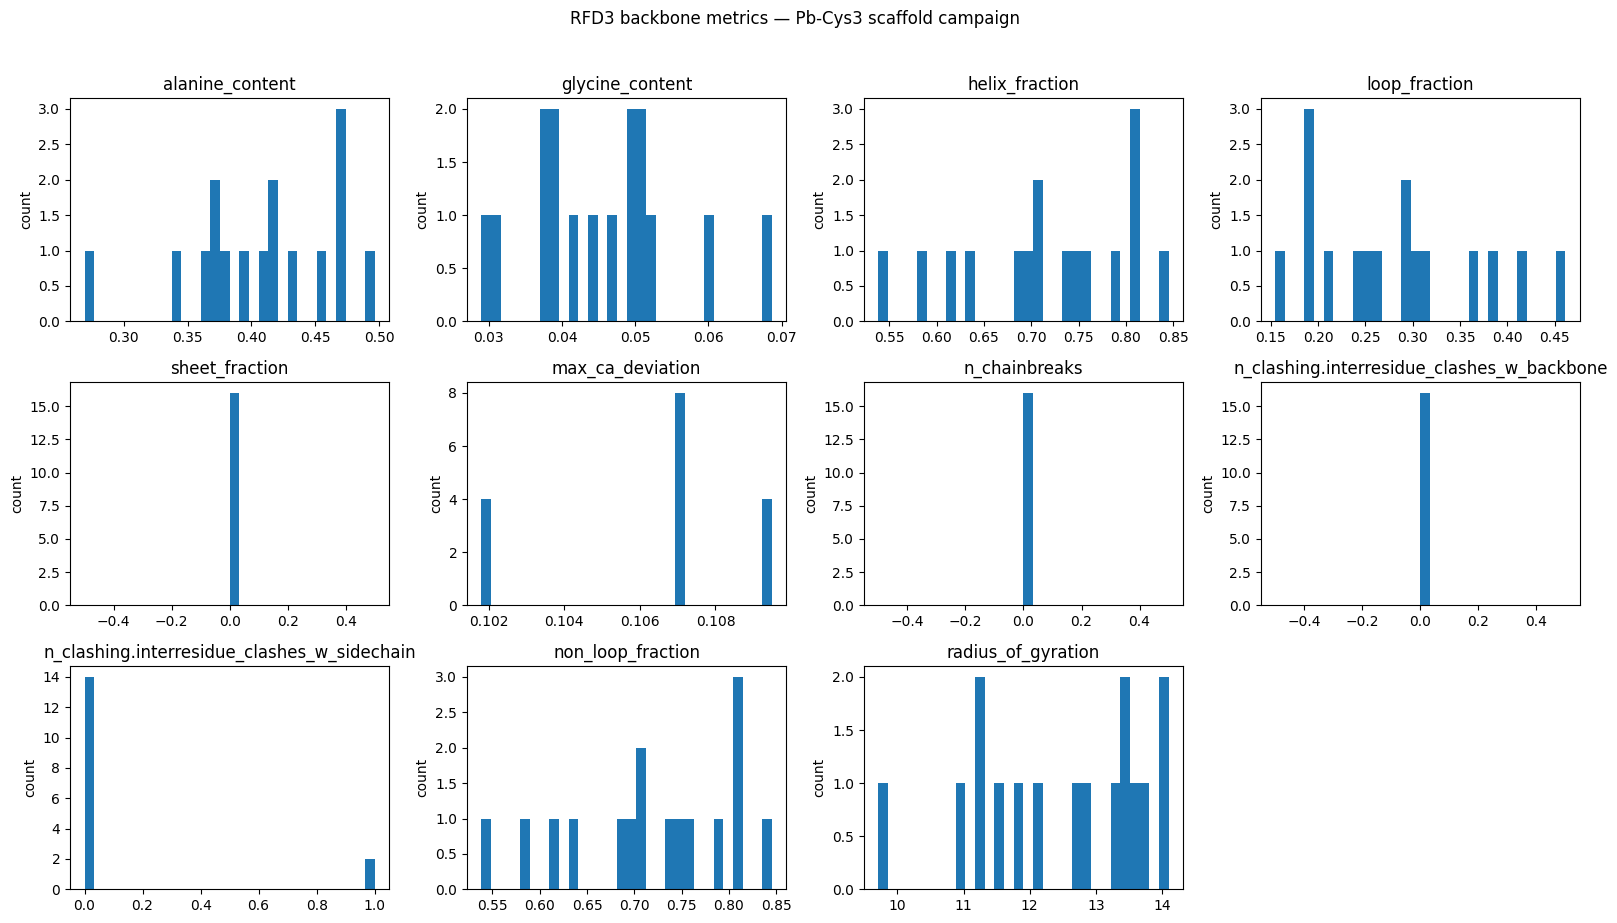

In [21]:
metrics = [
    "alanine_content",
    "glycine_content",
    "helix_fraction",
    "loop_fraction",
    "sheet_fraction",
    "max_ca_deviation",
    "n_chainbreaks",
    "n_clashing.interresidue_clashes_w_backbone",
    "n_clashing.interresidue_clashes_w_sidechain",
    "non_loop_fraction",
    "radius_of_gyration",
]

metrics = [metric for metric in metrics if metric in df_rfd3.columns]
print("Plotting:", metrics)

if metrics:
    n_cols = 4
    n_rows = math.ceil(len(metrics) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, metrics):
        series = df_rfd3[col].dropna()
        if series.empty:
            ax.set_title(f"{col} (no data)")
            ax.axis("off")
            continue
        ax.hist(series, bins=30)
        ax.set_title(col)
        ax.set_ylabel("count")

    for ax in axes[len(metrics):]:
        ax.axis("off")

    plt.suptitle("RFD3 backbone metrics — Pb-Cys3 scaffold campaign", y=1.02)
    plt.tight_layout()
    plt.show()

### Optional backbone filtering

This keeps structured, non-clashing backbones for MPNN.  
If nothing passes, the next cell falls back to all backbones.

In [9]:
df_filt = df_rfd3.copy()

# Basic designability filters.
if "loop_fraction" in df_filt.columns:
    df_filt = df_filt[df_filt["loop_fraction"] < 0.4]
if "non_loop_fraction" in df_filt.columns:
    df_filt = df_filt[df_filt["non_loop_fraction"] > 0.6]
if "n_clashing.interresidue_clashes_w_backbone" in df_filt.columns:
    df_filt = df_filt[df_filt["n_clashing.interresidue_clashes_w_backbone"] == 0]
if "n_clashing.interresidue_clashes_w_sidechain" in df_filt.columns:
    df_filt = df_filt[df_filt["n_clashing.interresidue_clashes_w_sidechain"] == 0]

df_filt = df_filt[df_filt["structure_path"].astype(str).str.len() > 0].copy()

print(f"Total RFD3 designs  : {len(df_rfd3)}")
print(f"Passing backbones   : {len(df_filt)}")

passing_csv = scores_dir / "rfd3_passing_backbones.csv"
df_filt.to_csv(passing_csv, index=False)
print(f"Passing CSV         : {passing_csv}")

df_filt.head()

Total RFD3 designs  : 16
Passing backbones   : 12
Passing CSV         : /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/rfd3_passing_backbones.csv


,condition,json_path,structure_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.496454,0.800059,-0.731369,-0.510821,5.113996,9.014856,-2.913921,0.049645,0.811321,0.188679,0.107031,0,0,0,0.811321,141,5,14.099353,0.0
1,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.457143,-0.654161,-0.778662,-3.853013,5.113996,9.014856,-2.913921,0.038095,0.814286,0.185714,0.107031,0,0,0,0.814286,105,6,12.686934,0.0
2,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.408163,0.242436,-1.852085,-7.066871,5.113996,9.014856,-2.913921,0.051020,0.793651,0.206349,0.107031,0,0,0,0.793651,98,5,10.911148,0.0
3,w6_scaffold-side-12A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.469231,1.179567,-1.308523,-1.284929,5.113996,9.014856,-2.913921,0.038462,0.810526,0.189474,0.107031,0,0,0,0.810526,130,7,13.413426,0.0
5,w6_scaffold-side-15A,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.375000,-0.297685,1.708532,-5.680187,6.261300,11.585849,-3.948044,0.031250,0.704918,0.295082,0.101812,0,0,0,0.704918,96,5,11.477216,0.0


## 4. ProteinMPNN — design sequences on scaffold chain A

ProteinMPNN redesigns only **chain A**, the generated scaffold.

Chains C and D are fixed context from 5GPE and should not be redesigned.

In [ ]:
import json
import pandas as pd
from pathlib import Path

# Use filtered backbones if available; otherwise use all backbones.
df_mpnn_input = df_filt.copy() if len(df_filt) > 0 else df_rfd3.copy()
df_mpnn_input = df_mpnn_input[df_mpnn_input["structure_path"].astype(str).str.len() > 0].copy()

if df_mpnn_input.empty:
    raise SystemExit("No RFD3 structures available for MPNN.")

# Fix only the Pb-binding Cys3 motif first.
# D113 and D122 mean chain D residues 113/122, not Asp residues.
MOTIF_FIXED_KEYS = ["C78", "C82", "D113", "D122"]

# Optional later, not first:
# MOTIF_FIXED_KEYS = ["C78", "D113", "D117", "D122"]

mpnn_cmds = cmds_dir / "mpnn.cmds"
fixed_report_rows = []

with mpnn_cmds.open("w") as handle:
    for _, row in df_mpnn_input.iterrows():
        structure = Path(row["structure_path"])
        condition = row["condition"]
        backbone_name = structure.name.replace(".cif.gz", "").replace(".cif", "")
        this_out = mpnn_out_dir / condition / backbone_name
        this_out.mkdir(parents=True, exist_ok=True)

        json_path = Path(row["json_path"])

        if not json_path.exists():
            raise FileNotFoundError(f"Missing RFD3 JSON with diffused_index_map: {json_path}")

        with json_path.open() as f:
            rfd3_data = json.load(f)

        mapping = rfd3_data["diffused_index_map"]

        missing_keys = [k for k in MOTIF_FIXED_KEYS if k not in mapping]
        if missing_keys:
            raise KeyError(f"Missing motif keys in {json_path}: {missing_keys}")

        fixed_residues = ",".join(mapping[k] for k in MOTIF_FIXED_KEYS)

        fixed_report_rows.append({
            "condition": condition,
            "backbone_name": backbone_name,
            "structure_path": str(structure),
            "json_path": str(json_path),
            "fixed_keys": ",".join(MOTIF_FIXED_KEYS),
            "fixed_residues": fixed_residues,
        })

        cmd = (
            f'mpnn '
            f'--seed {MPNN_SEED} '
            f'--structure_path "{structure}" '
            f'--out_directory "{this_out}" '
            f'--batch_size {MPNN_BATCH_SIZE} '
            f'--number_of_batches {MPNN_NUMBER_OF_BATCHES} '
            f'--model_type protein_mpnn '
            f'--checkpoint_path "{PROTEINMPNN_CKPT}" '
            f'--is_legacy_weights True '
            f'--fixed_residues "{fixed_residues}"'
        )
        handle.write(cmd + "\n")

df_fixed_report = pd.DataFrame(fixed_report_rows)
fixed_report_path = scores_dir / "mpnn_fixed_residues_report.csv"
df_fixed_report.to_csv(fixed_report_path, index=False)

activate_mpnn = f"""
source "{CONDA_SH}"
conda activate "{MPNN_CONDA_ENV}"
"""

exports_mpnn = """
export DISABLE_CUEQUIVARIANCE=true
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
"""

mpnn_script = write_lsf_array_script(
    cmds_path=mpnn_cmds,
    script_path=submit_dir / "mpnn.sh",
    job_name="mpnn_pb_fixed_cys3",
    queue=QUEUE,
    cores=4,
    mem="10GB",
    time_limit="2:00",
    group_size=10,
    gpu_spec=None,
    activate_lines=activate_mpnn,
    extra_exports=exports_mpnn,
)

print(f"Wrote {mpnn_cmds}")
print(f"Wrote {mpnn_script}")
print(f"Fixed report: {fixed_report_path}")
print(f"Backbones going to MPNN: {len(df_mpnn_input)}")
print(f"Sequences per backbone : {MPNN_BATCH_SIZE * MPNN_NUMBER_OF_BATCHES}")
print("\nFixed residues preview:")
display(df_fixed_report.head(20))

print("\nSubmit:")
print(f"  bsub < {mpnn_script}")

Wrote /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/cmds/mpnn.cmds
Wrote /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/submit/mpnn.sh
Fixed report: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/mpnn_fixed_residues_report.csv
Backbones going to MPNN: 12
Sequences per backbone : 4

Fixed residues preview:


,condition,backbone_name,structure_path,json_path,fixed_keys,fixed_residues
0,w6_scaffold-side-12A,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A57 A61 A83 A92
1,w6_scaffold-side-12A,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A42 A46 A72 A81
2,w6_scaffold-side-12A,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A40 A44 A71 A80
3,w6_scaffold-side-12A,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A41 A45 A72 A81
4,w6_scaffold-side-15A,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A40 A44 A71 A80
5,w6_scaffold-side-15A,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A18 A22 A39 A48
6,w6_scaffold-side-15A,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A21 A25 A42 A51
7,w6_scaffold-side-5A,rfd3_input_w6_scaffold-side-5A_5gpe_pb_motif_r...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A22 A26 A52 A61
8,w6_scaffold-side-5A,rfd3_input_w6_scaffold-side-5A_5gpe_pb_motif_r...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A38 A42 A70 A79
9,w6_scaffold-side-8A,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122",A43 A47 A76 A85



Submit:
  bsub < /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/submit/mpnn.sh


In [81]:
# Run this after the MPNN job finishes.
fa_files = sorted(mpnn_out_dir.glob("**/*.fa"))
print(f"Found {len(fa_files)} FASTA file(s) under {mpnn_out_dir}")

for path in fa_files[:10]:
    print(" ", path)
if len(fa_files) > 10:
    print(f"  ... and {len(fa_files) - 10} more")
if not fa_files:
    print("No FASTAs found yet. Submit MPNN first, wait for it to finish, then rerun this cell.")

Found 0 FASTA file(s) under /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/mpnn_out
No FASTAs found yet. Submit MPNN first, wait for it to finish, then rerun this cell.


In [ ]:
def get_resname(arr, chain, res_id):
    mask = (arr.chain_id == chain) & (arr.res_id == res_id)
    if mask.sum() == 0:
        return None
    return str(arr.res_name[mask][0])


def has_atom(arr, chain, res_id, atom_name):
    mask = (
        (arr.chain_id == chain)
        & (arr.res_id == res_id)
        & (arr.atom_name == atom_name)
    )
    return bool(mask.sum() > 0)


motif_status_rows = []

for _, row in df_best_models.iterrows():
    design_id = row["design_id"]
    model_idx = int(row["model_idx"])
    rf3_struct = row["rf3_structure_path"]

    source_id = design_id.split("__")[0]

    if source_id not in rfd3_records:
        continue

    rec = rfd3_records[source_id]
    mapping = rec["mapping"]

    try:
        rf3_arr = load_atom_array(rf3_struct)

        mapped_labels = [mapping[k] for k in MOTIF_KEYS]
        mapped_res = [parse_chain_res(x) for x in mapped_labels]

        resnames = []
        has_sg = []

        for chain, res_id in mapped_res:
            resnames.append(get_resname(rf3_arr, chain, res_id))
            has_sg.append(has_atom(rf3_arr, chain, res_id, "SG"))

        motif_status_rows.append({
            "design_id": design_id,
            "model_idx": model_idx,
            "ptm": float(row["ptm"]),
            "mapped_C78": mapped_labels[0],
            "mapped_D113": mapped_labels[1],
            "mapped_D122": mapped_labels[2],
            "res_C78": resnames[0],
            "res_D113": resnames[1],
            "res_D122": resnames[2],
            "has_SG_C78": has_sg[0],
            "has_SG_D113": has_sg[1],
            "has_SG_D122": has_sg[2],
            "kept_cys3": all(r == "CYS" for r in resnames) and all(has_sg),
            "rf3_structure_path": rf3_struct,
        })

    except Exception as exc:
        motif_status_rows.append({
            "design_id": design_id,
            "model_idx": model_idx,
            "ptm": float(row["ptm"]),
            "error": str(exc),
            "kept_cys3": False,
            "rf3_structure_path": rf3_struct,
        })

df_motif_status = pd.DataFrame(motif_status_rows)

print(df_motif_status["kept_cys3"].value_counts(dropna=False))

df_motif_status[
    [
        "design_id",
        "model_idx",
        "ptm",
        "mapped_C78",
        "res_C78",
        "mapped_D113",
        "res_D113",
        "mapped_D122",
        "res_D122",
        "kept_cys3",
    ]
].head(20)

## 5. RF3 — fold scaffold + SpyTag with Pb-Cys₃ context

RF3 folds:

```text
Chain A: MPNN scaffold + GSGSGSAHIVMVDAYKPTK
Context: fixed C/D Pb-Cys3 motif PDB from the preparation stage
```

This checks whether the designed scaffold sequence remains compatible with the fixed Pb-binding context.

In [42]:
from copy import deepcopy
from pathlib import Path
import glob
import json
import os
import re

rf3_json_dir = Path(configs_dir) / "rf3"
rf3_json_dir.mkdir(parents=True, exist_ok=True)

# Monomeric RF3 template: one protein chain only.
# This replaces the old MMP9 binder-target template.
def make_monomer_rf3_json(name: str, seq: str) -> dict:
    return {
        "name": name,
        "components": [
            {
                "chain_id": "A",
                "seq": seq,
            }
        ],
    }

# Match MPNN FASTA header: >{name}_b{batch_idx}_d{design_idx}, ...
DESIGN_RE = re.compile(r"_b(\d+)_d(\d+)")

def parse_fasta(path):
    header, chunks = None, []

    with open(path) as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(chunks)

                header, chunks = line[1:], []
            else:
                chunks.append(line)

        if header is not None:
            yield header, "".join(chunks)

fa_files = sorted(glob.glob(os.path.join(mpnn_out_dir, "**", "*.fa"), recursive=True))

if not fa_files:
    raise SystemExit(f"No MPNN FASTAs under {mpnn_out_dir} — run MPNN first.")

written = 0
rf3_manifest_rows = []

for fa in fa_files:
    model_dir = os.path.basename(os.path.dirname(fa))

    for header, seq in parse_fasta(fa):
        m = DESIGN_RE.search(header)

        if not m:
            continue

        batch_idx = int(m.group(1))
        design_idx = int(m.group(2))

        # MPNN may return multichain sequences separated by ':'.
        # For our monomeric design, chain A is the first sequence.
        chain_a = seq.split(":", 1)[0]

        name = f"{model_dir}__b{batch_idx}_d{design_idx}"

        j = make_monomer_rf3_json(name=name, seq=chain_a)

        out_json = rf3_json_dir / f"{name}.json"

        with open(out_json, "w") as out:
            json.dump(j, out, indent=2)

        rf3_manifest_rows.append({
            "name": name,
            "rf3_json": str(out_json.resolve()),
            "mpnn_fasta": str(Path(fa).resolve()),
            "sequence": chain_a,
            "sequence_length": len(chain_a),
        })

        written += 1

rf3_manifest = pd.DataFrame(rf3_manifest_rows)
rf3_manifest_path = configs_dir / "rf3_manifest.csv"
rf3_manifest.to_csv(rf3_manifest_path, index=False)

print(f"Wrote {written} RF3 input JSONs -> {rf3_json_dir}")
print(f"RF3 manifest: {rf3_manifest_path}")

rf3_manifest.head()

Wrote 48 RF3 input JSONs -> /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/configs/rf3
RF3 manifest: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/configs/rf3_manifest.csv


,name,rf3_json,mpnn_fasta,sequence,sequence_length
0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,DAVATCEALRANREAAVAAAVAVLERRAAAASGAAAAELAALAAAV...,141
1,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,DAVATVDALRADAAAATAAAVALLEALAARASGAAAAALAALAAAL...,141
2,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,AAVATCAALQANAAAAVAKAVAVLRARAAAASGARAEALAALADAL...,141
3,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,AAVAEADALRANRAAAVAQAVAVLRARAAAASGKEREALLALAEAV...,141
4,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,AAAAARAAAAAAARARALLPPDLRAEWDAALAAAAAAPAAPSRPVR...,105


### Write the RF3 submit script

In [43]:
rf3_patch_dir = Path(configs_dir) / "rf3_python_patch"
rf3_patch_dir.mkdir(parents=True, exist_ok=True)

sitecustomize = rf3_patch_dir / "sitecustomize.py"

sitecustomize.write_text(
    """
# Auto-loaded by Python when this directory is in PYTHONPATH.
# Workaround for A100 MIG slices where pynvml.nvmlDeviceGetNumGpuCores is unsupported.

try:
    import pynvml

    def _safe_nvmlDeviceGetNumGpuCores(handle):
        # Approximate SM count for A100 MIG 2g.20gb.
        # Used only for cuEquivariance tuning metadata.
        return 28

    pynvml.nvmlDeviceGetNumGpuCores = _safe_nvmlDeviceGetNumGpuCores

except Exception:
    pass
"""
)

print("Wrote RF3 Python patch:", sitecustomize)

Wrote RF3 Python patch: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/configs/rf3_python_patch/sitecustomize.py


In [44]:
queue       = "c27666"
job_name    = "rf3"
time_limit  = "2:00"
mem         = "10GB"
gpu_spec    = "num=1:mode=exclusive_process"
cores       = 4
group_size  = 20

rf3_release = "/dtu/projects/dbl/rf3/release"
ckpt_path   = "/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt"
num_steps   = 50

json_files = sorted(Path(rf3_json_dir).glob("*.json"))

if not json_files:
    raise SystemExit(f"No RF3 JSONs in {rf3_json_dir}")

cmds_path = Path(cmds_dir) / "rf3.cmds"

lines = []

for jf in json_files:
    out_dir = Path(rf3_out_dir) / jf.stem

    lines.append(
        f"python {REPO_ROOT}/scripts/lib/rf3_wrapper.py fold "
        f"inference_engine=rf3 "
        f"inputs={jf} "
        f"out_dir={out_dir} "
        f"ckpt_path={ckpt_path} "
        f"num_steps={num_steps} "
        f"annotate_b_factor_with_plddt=True "
        f"early_stopping_plddt_threshold=0"
    )

cmds_path.write_text("\n".join(lines) + "\n")

n_arrays = math.ceil(len(lines) / group_size)

script = f"""#!/bin/bash
#BSUB -q {queue}
#BSUB -J {job_name}[1-{n_arrays}]
#BSUB -n {cores}
#BSUB -gpu "{gpu_spec}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J_%I.out
#BSUB -e {logs_dir}/%J_%I.err

set -eu

mkdir -p {logs_dir}
module load cuda/12.4

# RF3 activate_env.sh expects PYTHONPATH to exist.
export PYTHONPATH="${{PYTHONPATH:-}}"

# Monkeypatch pynvml before RF3 imports cuequivariance.
export PYTHONPATH="{rf3_patch_dir}:${{PYTHONPATH}}"

# RF3 uses its own dedicated environment.
set +u
source {rf3_release}/activate_env.sh
set -u

export DISABLE_CUEQUIVARIANCE=true
export PYTORCH_ALLOC_CONF=expandable_segments:True
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

CMDS_FILE={cmds_path}
GROUP_SIZE={group_size}
START=$(( (LSB_JOBINDEX - 1) * GROUP_SIZE ))
END=$(( START + GROUP_SIZE ))

i=0
while IFS= read -r cmd; do
    if [ "$i" -ge "$START" ] && [ "$i" -lt "$END" ]; then
        echo "Running command index $i"
        echo "$cmd"
        eval "$cmd"
    fi
    i=$((i+1))
done < "$CMDS_FILE"

echo "Done at $(date)"
"""

sub = Path(submit_dir) / "rf3.sh"
sub.write_text(script)

print(f"{len(lines)} RF3 folds in {n_arrays} array task(s).")
print("Commands:", cmds_path)
print("Submit:")
print("  bsub < " + str(sub))

48 RF3 folds in 3 array task(s).
Commands: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/cmds/rf3.cmds
Submit:
  bsub < /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/submit/rf3.sh


## 6. Gather RF3 metrics

This cell tries to use `rf3_metrics.gather_rf3_metrics` if it exists.  
If your project does not have that helper, copy it from the course repo or replace this cell with your local RF3 scoring script.

Expected chain IDs:

```text
A_1 = scaffold + SpyTag
B_1 = chain C context, contains Cys78
C_1 = chain D context, contains Cys113/Cys122
D_1 = Pb²⁺ ion
```

In [4]:
import json
import pandas as pd
from pathlib import Path

def flatten_scalar_dict(d, prefix=""):
    out = {}

    if not isinstance(d, dict):
        return out

    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else str(k)

        if isinstance(v, dict):
            out.update(flatten_scalar_dict(v, key))
        elif isinstance(v, (str, int, float, bool)) or v is None:
            out[key] = v
        elif isinstance(v, list) and len(v) <= 20:
            out[key] = str(v)

    return out


def read_score_or_json(path):
    """
    RF3 .score files are often JSON-like.
    This tries JSON first. If it fails, it parses simple key:value / key whitespace value lines.
    """
    text = Path(path).read_text().strip()

    # Try JSON
    try:
        return json.loads(text)
    except Exception:
        pass

    # Fallback: parse plain text score file
    data = {}

    for line in text.splitlines():
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        if ":" in line:
            k, v = line.split(":", 1)
        else:
            parts = line.split(None, 1)
            if len(parts) != 2:
                continue
            k, v = parts

        k = k.strip()
        v = v.strip()

        try:
            v = float(v)
        except ValueError:
            pass

        data[k] = v

    return data


OUT_CSV = scores_dir / "rf3_gathered_scores.csv"

rows = []

score_files = sorted(Path(rf3_out_dir).glob("**/*.score"))
json_files = sorted(Path(rf3_out_dir).glob("**/*.json"))

print("Score files:", len(score_files))
print("JSON files:", len(json_files))

# Main RF3 metrics: .score
for p in score_files:
    try:
        data = read_score_or_json(p)
    except Exception as exc:
        print(f"[WARNING] Could not read {p}: {exc}")
        continue

    row = flatten_scalar_dict(data)
    row["score_path"] = str(p)
    row["score_file"] = p.name
    row["design_id"] = p.parent.name
    rows.append(row)

# Optional extra JSON outputs, if any exist
for p in json_files:
    try:
        with open(p) as handle:
            data = json.load(handle)
    except Exception as exc:
        print(f"[WARNING] Could not read {p}: {exc}")
        continue

    row = flatten_scalar_dict(data)
    row["json_path"] = str(p)
    row["json_file"] = p.name
    row["design_id"] = p.parent.name
    row["source_type"] = "json"
    rows.append(row)

df_rf3 = pd.DataFrame(rows)

# Add condition metadata from manifest, if available
if not df_rf3.empty:
    if "rf3_manifest" in globals() and "name" in rf3_manifest.columns:
        if "condition" in rf3_manifest.columns:
            condition_map = dict(zip(rf3_manifest["name"], rf3_manifest["condition"]))
            df_rf3["condition"] = df_rf3["design_id"].map(condition_map)

    df_rf3.to_csv(OUT_CSV, index=False)

print(f"{len(df_rf3)} RF3 metric record(s) gathered")
print(f"Metrics CSV: {OUT_CSV}")

df_rf3.head()

Score files: 48
JSON files: 0
48 RF3 metric record(s) gathered
Metrics CSV: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/rf3_gathered_scores.csv


,score_path,score_file,design_id
0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...
1,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...
2,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...
3,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...
4,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...


In [5]:
import pandas as pd
from pathlib import Path

rf3_out = Path(rf3_out_dir)

metric_files = sorted(rf3_out.glob("**/*_metrics.csv"))

print("RF3 metrics CSV files:", len(metric_files))

rows = []

for p in metric_files:
    try:
        tmp = pd.read_csv(p)
    except Exception as exc:
        print(f"[WARNING] Could not read {p}: {exc}")
        continue

    tmp["design_id"] = p.parent.name
    tmp["metrics_path"] = str(p)

    rows.append(tmp)

if not rows:
    raise RuntimeError("No RF3 *_metrics.csv files found/read.")

df_rf3_metrics = pd.concat(rows, ignore_index=True)

OUT_CSV = scores_dir / "rf3_gathered_metrics_csv.csv"
df_rf3_metrics.to_csv(OUT_CSV, index=False)

print("Rows:", len(df_rf3_metrics))
print("Columns:", df_rf3_metrics.columns.tolist())
print("Saved:", OUT_CSV)

df_rf3_metrics.head()

RF3 metrics CSV files: 48
Rows: 48
Columns: ['example_id', 'ptm.ptm_0', 'ptm.ptm_1', 'ptm.ptm_2', 'ptm.ptm_3', 'ptm.ptm_4', 'iptm.iptm_0', 'iptm.iptm_1', 'iptm.iptm_2', 'iptm.iptm_3', 'iptm.iptm_4', 'iptm.iptm_protein_protein_0', 'iptm.iptm_protein_protein_1', 'iptm.iptm_protein_protein_2', 'iptm.iptm_protein_protein_3', 'iptm.iptm_protein_protein_4', 'iptm.iptm_protein_ligand_0', 'iptm.iptm_protein_ligand_1', 'iptm.iptm_protein_ligand_2', 'iptm.iptm_protein_ligand_3', 'iptm.iptm_protein_ligand_4', 'iptm.iptm_ligand_ligand_0', 'iptm.iptm_ligand_ligand_1', 'iptm.iptm_ligand_ligand_2', 'iptm.iptm_ligand_ligand_3', 'iptm.iptm_ligand_ligand_4', 'count_clashing_chains.has_clash_0', 'count_clashing_chains.has_clash_1', 'count_clashing_chains.has_clash_2', 'count_clashing_chains.has_clash_3', 'count_clashing_chains.has_clash_4', 'design_id', 'metrics_path']
Saved: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/rf3_gathered_metrics_csv.csv


,example_id,ptm.ptm_0,ptm.ptm_1,ptm.ptm_2,ptm.ptm_3,ptm.ptm_4,iptm.iptm_0,iptm.iptm_1,iptm.iptm_2,iptm.iptm_3,iptm.iptm_4,iptm.iptm_protein_protein_0,iptm.iptm_protein_protein_1,iptm.iptm_protein_protein_2,iptm.iptm_protein_protein_3,iptm.iptm_protein_protein_4,iptm.iptm_protein_ligand_0,iptm.iptm_protein_ligand_1,iptm.iptm_protein_ligand_2,iptm.iptm_protein_ligand_3,iptm.iptm_protein_ligand_4,iptm.iptm_ligand_ligand_0,iptm.iptm_ligand_ligand_1,iptm.iptm_ligand_ligand_2,iptm.iptm_ligand_ligand_3,iptm.iptm_ligand_ligand_4,count_clashing_chains.has_clash_0,count_clashing_chains.has_clash_1,count_clashing_chains.has_clash_2,count_clashing_chains.has_clash_3,count_clashing_chains.has_clash_4,design_id,metrics_path
0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,0.617679,0.583304,0.631873,0.630673,0.574696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...
1,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,0.550222,0.570240,0.591760,0.560385,0.595992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...
2,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,0.805087,0.802355,0.807420,0.803450,0.804901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...
3,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,0.641204,0.601222,0.632480,0.610262,0.596385,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...
4,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,0.858686,0.859340,0.858764,0.860019,0.855388,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,/dtu/blackhole/00/222976/lead_sensoring/work/e...


### RF3 plots

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path

df = df_rf3_metrics.copy()

rows = []

for _, r in df.iterrows():
    design_id = r["design_id"]
    out_dir = Path(r["metrics_path"]).parent

    for model_idx in range(5):
        ptm = r.get(f"ptm.ptm_{model_idx}", np.nan)
        has_clash = r.get(f"count_clashing_chains.has_clash_{model_idx}", np.nan)

        struct_path = out_dir / f"{design_id}_model_{model_idx}.cif.gz"

        rows.append({
            "design_id": design_id,
            "model_idx": model_idx,
            "ptm": float(ptm) if pd.notna(ptm) else np.nan,
            "has_clash": int(has_clash) if pd.notna(has_clash) else np.nan,
            "rf3_structure_path": str(struct_path),
            "structure_exists": struct_path.exists(),
            "metrics_path": r["metrics_path"],
        })

df_rf3_models = pd.DataFrame(rows)

df_best_models = (
    df_rf3_models
    .sort_values(["has_clash", "ptm"], ascending=[True, False])
    .groupby("design_id", as_index=False)
    .head(1)
    .copy()
)

OUT_BEST_MODELS = scores_dir / "rf3_best_model_per_design.csv"
df_best_models.to_csv(OUT_BEST_MODELS, index=False)

print("RF3 model rows:", len(df_rf3_models))
print("Best models:", len(df_best_models))
print("Saved:", OUT_BEST_MODELS)

df_best_models.head(20)

RF3 model rows: 240
Best models: 48
Saved: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/rf3_best_model_per_design.csv


,design_id,model_idx,ptm,has_clash,rf3_structure_path,structure_exists,metrics_path
62,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,2,0.965575,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
181,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,1,0.952540,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
50,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,0,0.950171,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
225,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,0,0.949340,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
96,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,1,0.946807,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
81,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,1,0.942327,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
59,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,4,0.940298,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
234,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,4,0.939142,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
77,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,2,0.938006,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...
114,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,4,0.935662,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,True,/dtu/blackhole/00/222976/lead_sensoring/work/e...


In [7]:
import sys
from pathlib import Path

LIB_DIR = Path.cwd() / "lib"

if not LIB_DIR.exists():
    LIB_DIR = PROJECT_ROOT / "scripts" / "lib"

assert LIB_DIR.exists(), f"Missing lib dir: {LIB_DIR}"

if str(LIB_DIR) not in sys.path:
    sys.path.insert(0, str(LIB_DIR))

from motif_scan import (
    compute_triad_angles,
    compute_hemidirected_vectors,
    score_pb_s_distances,
    score_hemidirected_vectors,
    classify_geometry,
)

print("Imported motif_scan from:", LIB_DIR)

Imported motif_scan from: /dtu/blackhole/00/222976/lead_sensoring/scripts/lib


In [18]:
import json
import gzip
import shutil
import tempfile
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path

import biotite.structure as struc
import biotite.structure.io as strucio


# -----------------------------
# Load structures
# -----------------------------

def load_atom_array(path):
    path = Path(path)

    if path.suffix == ".gz":
        suffixes = path.suffixes
        inner_suffix = suffixes[-2] if len(suffixes) >= 2 else ".cif"

        with gzip.open(path, "rb") as fin:
            with tempfile.NamedTemporaryFile(suffix=inner_suffix, delete=False) as fout:
                shutil.copyfileobj(fin, fout)
                tmp_path = fout.name

        try:
            arr = strucio.load_structure(tmp_path)
        finally:
            os.remove(tmp_path)
    else:
        arr = strucio.load_structure(str(path))

    if isinstance(arr, struc.AtomArrayStack):
        arr = arr[0]

    return arr


def parse_chain_res(label):
    return label[0], int(label[1:])


def get_atom_coord(arr, chain, res_id, atom_name):
    mask = (
        (arr.chain_id == chain)
        & (arr.res_id == res_id)
        & (arr.atom_name == atom_name)
    )

    if mask.sum() == 0:
        raise ValueError(f"Missing atom {chain}{res_id}@{atom_name}")

    return arr.coord[mask][0]


def get_resname(arr, chain, res_id):
    mask = (arr.chain_id == chain) & (arr.res_id == res_id)
    if mask.sum() == 0:
        return None
    return str(arr.res_name[mask][0])


def kabsch_rmsd(P, Q):
    P = np.asarray(P, float)
    Q = np.asarray(Q, float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    H = Pc.T @ Qc
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = Q.mean(axis=0) - P.mean(axis=0) @ R
    P_fit = P @ R + t

    rmsd = np.sqrt(np.mean(np.sum((P_fit - Q) ** 2, axis=1)))
    return float(rmsd)


def strip_rf3_design_suffix(design_id):
    # rfd3_input_..._model_0__b1_d1 -> rfd3_input_..._model_0
    return re.sub(r"__b\d+_d\d+$", "", design_id)


def strip_cif_suffix(path):
    name = Path(path).name
    name = name.replace(".cif.gz", "")
    name = name.replace(".pdb.gz", "")
    name = name.replace(".cif", "")
    name = name.replace(".pdb", "")
    return name

In [22]:
# -----------------------------
# Build robust RFD3 mapping records
# -----------------------------

rfd3_records = {}

for _, row in df_rfd3.iterrows():
    json_path = Path(row["json_path"])
    structure_path = Path(row["structure_path"])

    with json_path.open() as f:
        data = json.load(f)

    if "diffused_index_map" not in data:
        continue

    # Store by JSON stem
    rfd3_records[json_path.stem] = {
        "json_path": str(json_path),
        "structure_path": str(structure_path),
        "condition": row.get("condition", None),
        "mapping": data["diffused_index_map"],
    }

    # Store also by structure basename, usually this matches RF3 source_id
    rfd3_records[strip_cif_suffix(structure_path)] = {
        "json_path": str(json_path),
        "structure_path": str(structure_path),
        "condition": row.get("condition", None),
        "mapping": data["diffused_index_map"],
    }

print("RFD3 record keys:", len(rfd3_records))
print(list(rfd3_records.keys())[:5])

RFD3 record keys: 16
['rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_r5_scaffold-side-12A_0_model_0', 'rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_r5_scaffold-side-12A_1_model_0', 'rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_r5_scaffold-side-12A_2_model_0', 'rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_r5_scaffold-side-12A_3_model_0', 'rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_r5_scaffold-side-15A_0_model_0']


In [24]:
# -----------------------------
# RMSD: WT/context motif/window vs RF3 design
# -----------------------------

WT_CONTEXT_PDB = Path(
    "/dtu/blackhole/00/222976/lead_sensoring/work/exp_01/contexts/rfd3_context_fixed_segments_plus_pb.pdb"
)

assert WT_CONTEXT_PDB.exists(), WT_CONTEXT_PDB

wt_arr = load_atom_array(WT_CONTEXT_PDB)

# Local key residues
MOTIF_KEYS = ["C78", "C82", "D113", "D122"]       # Cys + Asn
CYS_KEYS = ["C78", "D113", "D122"]                # Pb Cys3 only

# Larger transplanted windows
WINDOW_KEYS = (
    [f"C{i}" for i in range(72, 85)]
    + [f"D{i}" for i in range(107, 129)]
)

BACKBONE_ATOMS = ["N", "CA", "C", "O"]
SIDECHAIN_CHECK_ATOMS = {
    "C78": ["CB", "SG"],
    "D113": ["CB", "SG"],
    "D122": ["CB", "SG"],
    "C82": ["CB", "CG", "OD1", "ND2"],  # Asn82
}


def collect_coords_by_mapping(wt_arr, rf3_arr, mapping, keys, atom_names):
    P = []
    Q = []
    used = []
    missing = []

    for key in keys:
        if key not in mapping:
            missing.append((key, "missing_mapping"))
            continue

        wt_chain, wt_res = parse_chain_res(key)
        rf3_chain, rf3_res = parse_chain_res(mapping[key])

        for atom in atom_names:
            try:
                P.append(get_atom_coord(wt_arr, wt_chain, wt_res, atom))
                Q.append(get_atom_coord(rf3_arr, rf3_chain, rf3_res, atom))
                used.append((key, mapping[key], atom))
            except Exception as exc:
                missing.append((key, mapping[key], atom, str(exc)))

    if len(P) == 0:
        return None, None, used, missing

    return np.array(P), np.array(Q), used, missing


rmsd_rows = []

for _, row in df_best_models.iterrows():
    design_id = row["design_id"]
    model_idx = int(row["model_idx"])
    rf3_path = Path(row["rf3_structure_path"])

    if not rf3_path.exists():
        print("[WARNING] Missing RF3 structure:", rf3_path)
        continue

    source_id = strip_rf3_design_suffix(design_id)

    if source_id not in rfd3_records:
        print("[WARNING] Missing RFD3 source:", source_id)
        continue

    rec = rfd3_records[source_id]
    mapping = rec["mapping"]

    try:
        rf3_arr = load_atom_array(rf3_path)

        # Identity checks
        identity = {}
        for key in MOTIF_KEYS:
            mapped = mapping[key]
            chain, res_id = parse_chain_res(mapped)
            identity[f"mapped_{key}"] = mapped
            identity[f"res_{key}"] = get_resname(rf3_arr, chain, res_id)

        kept_cys3 = (
            identity["res_C78"] == "CYS"
            and identity["res_D113"] == "CYS"
            and identity["res_D122"] == "CYS"
        )

        kept_asn82 = identity["res_C82"] == "ASN"

        # 1) Cys3 backbone RMSD
        P, Q, used, missing = collect_coords_by_mapping(
            wt_arr, rf3_arr, mapping, CYS_KEYS, BACKBONE_ATOMS
        )
        cys3_backbone_rmsd = kabsch_rmsd(P, Q) if P is not None else np.nan

        # 2) Cys3 + Asn82 backbone RMSD
        P, Q, used, missing = collect_coords_by_mapping(
            wt_arr, rf3_arr, mapping, MOTIF_KEYS, BACKBONE_ATOMS
        )
        motif4_backbone_rmsd = kabsch_rmsd(P, Q) if P is not None else np.nan

        # 3) Whole transplanted window backbone RMSD
        P, Q, used, missing_window = collect_coords_by_mapping(
            wt_arr, rf3_arr, mapping, WINDOW_KEYS, BACKBONE_ATOMS
        )
        window_backbone_rmsd = kabsch_rmsd(P, Q) if P is not None else np.nan
        n_window_atoms_used = len(used)
        n_window_missing = len(missing_window)

        # 4) Sidechain RMSD only if atoms exist
        sidechain_P = []
        sidechain_Q = []
        sidechain_missing = []

        for key, atoms in SIDECHAIN_CHECK_ATOMS.items():
            mapped = mapping[key]
            wt_chain, wt_res = parse_chain_res(key)
            rf3_chain, rf3_res = parse_chain_res(mapped)

            for atom in atoms:
                try:
                    sidechain_P.append(get_atom_coord(wt_arr, wt_chain, wt_res, atom))
                    sidechain_Q.append(get_atom_coord(rf3_arr, rf3_chain, rf3_res, atom))
                except Exception as exc:
                    sidechain_missing.append((key, mapped, atom, str(exc)))

        sidechain_rmsd = (
            kabsch_rmsd(np.array(sidechain_P), np.array(sidechain_Q))
            if len(sidechain_P) >= 3
            else np.nan
        )

        rmsd_rows.append({
            "design_id": design_id,
            "source_id": source_id,
            "condition": rec.get("condition", None),
            "model_idx": model_idx,
            "ptm": float(row["ptm"]),
            "has_clash": int(row["has_clash"]),
            "rf3_structure_path": str(rf3_path),
            "wt_context_path": str(WT_CONTEXT_PDB),

            **identity,

            "kept_cys3": kept_cys3,
            "kept_asn82": kept_asn82,

            "cys3_backbone_rmsd": cys3_backbone_rmsd,
            "motif4_backbone_rmsd": motif4_backbone_rmsd,
            "window_backbone_rmsd": window_backbone_rmsd,
            "sidechain_rmsd_available_atoms": sidechain_rmsd,

            "n_window_atoms_used": n_window_atoms_used,
            "n_window_missing": n_window_missing,
            "n_sidechain_missing_atoms": len(sidechain_missing),
            "sidechain_missing_atoms": str(sidechain_missing[:10]),
        })

    except Exception as exc:
        print("[FAILED]", design_id, model_idx, exc)

df_rmsd = pd.DataFrame(rmsd_rows)

OUT_RMSD = scores_dir / "rf3_wt_context_rmsd.csv"
df_rmsd.to_csv(OUT_RMSD, index=False)

print("Evaluated:", len(df_rmsd))
print("Saved:", OUT_RMSD)

df_rmsd.head()

Evaluated: 48
Saved: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/rf3_wt_context_rmsd.csv


,design_id,source_id,condition,model_idx,ptm,has_clash,rf3_structure_path,wt_context_path,mapped_C78,res_C78,mapped_C82,res_C82,mapped_D113,res_D113,mapped_D122,res_D122,kept_cys3,kept_asn82,cys3_backbone_rmsd,motif4_backbone_rmsd,window_backbone_rmsd,sidechain_rmsd_available_atoms,n_window_atoms_used,n_window_missing,n_sidechain_missing_atoms,sidechain_missing_atoms
0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,w6_scaffold-side-12A,2,0.965575,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A41,CYS,A45,ASN,A72,CYS,A81,CYS,True,True,1.888930,1.989537,3.116052,0.804161,140,0,0,[]
1,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,w6_scaffold-side-8A,1,0.952540,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A43,CYS,A47,ASN,A76,CYS,A85,CYS,True,True,6.388350,7.557011,11.807670,4.482871,140,0,0,[]
2,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,w6_scaffold-side-12A,0,0.950171,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A40,CYS,A44,ASN,A71,CYS,A80,CYS,True,True,7.200051,8.000941,14.100763,4.687754,140,0,0,[]
3,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,w6_scaffold-side-8A,0,0.949340,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A53,CYS,A57,ASN,A73,CYS,A82,CYS,True,True,8.645829,8.614524,14.796882,6.548996,140,0,0,[]
4,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,w6_scaffold-side-15A,1,0.946807,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A40,CYS,A44,ASN,A71,CYS,A80,CYS,True,True,0.501691,1.069927,1.282976,1.276652,140,0,0,[]


In [27]:
import json
import gzip
import shutil
import tempfile
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path

import biotite.structure as struc
import biotite.structure.io as strucio


# -----------------------------
# Load structures
# -----------------------------

def load_atom_array(path):
    path = Path(path)

    if path.suffix == ".gz":
        suffixes = path.suffixes
        inner_suffix = suffixes[-2] if len(suffixes) >= 2 else ".cif"

        with gzip.open(path, "rb") as fin:
            with tempfile.NamedTemporaryFile(suffix=inner_suffix, delete=False) as fout:
                shutil.copyfileobj(fin, fout)
                tmp_path = fout.name

        try:
            arr = strucio.load_structure(tmp_path)
        finally:
            os.remove(tmp_path)
    else:
        arr = strucio.load_structure(str(path))

    if isinstance(arr, struc.AtomArrayStack):
        arr = arr[0]

    return arr


def parse_chain_res(label):
    return label[0], int(label[1:])


def get_atom_coord(arr, chain, res_id, atom_name):
    mask = (
        (arr.chain_id == chain)
        & (arr.res_id == res_id)
        & (arr.atom_name == atom_name)
    )

    if mask.sum() == 0:
        raise ValueError(f"Missing atom {chain}{res_id}@{atom_name}")

    return arr.coord[mask][0]


def get_resname(arr, chain, res_id):
    mask = (arr.chain_id == chain) & (arr.res_id == res_id)
    if mask.sum() == 0:
        return None
    return str(arr.res_name[mask][0])


def kabsch_rmsd(P, Q):
    P = np.asarray(P, float)
    Q = np.asarray(Q, float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    H = Pc.T @ Qc
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = Q.mean(axis=0) - P.mean(axis=0) @ R
    P_fit = P @ R + t

    rmsd = np.sqrt(np.mean(np.sum((P_fit - Q) ** 2, axis=1)))
    return float(rmsd)


def strip_rf3_design_suffix(design_id):
    # rfd3_input_..._model_0__b1_d1 -> rfd3_input_..._model_0
    return re.sub(r"__b\d+_d\d+$", "", design_id)


def strip_cif_suffix(path):
    name = Path(path).name
    name = name.replace(".cif.gz", "")
    name = name.replace(".pdb.gz", "")
    name = name.replace(".cif", "")
    name = name.replace(".pdb", "")
    return name

In [28]:
import json
import gzip
import shutil
import tempfile
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path

import biotite.structure as struc
import biotite.structure.io as strucio


# -----------------------------
# Load structures
# -----------------------------

def load_atom_array(path):
    path = Path(path)

    if path.suffix == ".gz":
        suffixes = path.suffixes
        inner_suffix = suffixes[-2] if len(suffixes) >= 2 else ".cif"

        with gzip.open(path, "rb") as fin:
            with tempfile.NamedTemporaryFile(suffix=inner_suffix, delete=False) as fout:
                shutil.copyfileobj(fin, fout)
                tmp_path = fout.name

        try:
            arr = strucio.load_structure(tmp_path)
        finally:
            os.remove(tmp_path)
    else:
        arr = strucio.load_structure(str(path))

    if isinstance(arr, struc.AtomArrayStack):
        arr = arr[0]

    return arr


def parse_chain_res(label):
    return label[0], int(label[1:])


def get_atom_coord(arr, chain, res_id, atom_name):
    mask = (
        (arr.chain_id == chain)
        & (arr.res_id == res_id)
        & (arr.atom_name == atom_name)
    )

    if mask.sum() == 0:
        raise ValueError(f"Missing atom {chain}{res_id}@{atom_name}")

    return arr.coord[mask][0]


def get_resname(arr, chain, res_id):
    mask = (arr.chain_id == chain) & (arr.res_id == res_id)
    if mask.sum() == 0:
        return None
    return str(arr.res_name[mask][0])


def kabsch_rmsd(P, Q):
    P = np.asarray(P, float)
    Q = np.asarray(Q, float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    H = Pc.T @ Qc
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = Q.mean(axis=0) - P.mean(axis=0) @ R
    P_fit = P @ R + t

    rmsd = np.sqrt(np.mean(np.sum((P_fit - Q) ** 2, axis=1)))
    return float(rmsd)


def strip_rf3_design_suffix(design_id):
    # rfd3_input_..._model_0__b1_d1 -> rfd3_input_..._model_0
    return re.sub(r"__b\d+_d\d+$", "", design_id)


def strip_cif_suffix(path):
    name = Path(path).name
    name = name.replace(".cif.gz", "")
    name = name.replace(".pdb.gz", "")
    name = name.replace(".cif", "")
    name = name.replace(".pdb", "")
    return name

In [29]:
# -----------------------------
# RMSD: WT/context motif/window vs RF3 design
# -----------------------------

WT_CONTEXT_PDB = Path(
    "/dtu/blackhole/00/222976/lead_sensoring/work/exp_01/contexts/rfd3_context_fixed_segments_plus_pb.pdb"
)

assert WT_CONTEXT_PDB.exists(), WT_CONTEXT_PDB

wt_arr = load_atom_array(WT_CONTEXT_PDB)

# Local key residues
MOTIF_KEYS = ["C78", "C82", "D113", "D122"]       # Cys + Asn
CYS_KEYS = ["C78", "D113", "D122"]                # Pb Cys3 only

# Larger transplanted windows
WINDOW_KEYS = (
    [f"C{i}" for i in range(72, 85)]
    + [f"D{i}" for i in range(107, 129)]
)

BACKBONE_ATOMS = ["N", "CA", "C", "O"]
SIDECHAIN_CHECK_ATOMS = {
    "C78": ["CB", "SG"],
    "D113": ["CB", "SG"],
    "D122": ["CB", "SG"],
    "C82": ["CB", "CG", "OD1", "ND2"],  # Asn82
}


def collect_coords_by_mapping(wt_arr, rf3_arr, mapping, keys, atom_names):
    P = []
    Q = []
    used = []
    missing = []

    for key in keys:
        if key not in mapping:
            missing.append((key, "missing_mapping"))
            continue

        wt_chain, wt_res = parse_chain_res(key)
        rf3_chain, rf3_res = parse_chain_res(mapping[key])

        for atom in atom_names:
            try:
                P.append(get_atom_coord(wt_arr, wt_chain, wt_res, atom))
                Q.append(get_atom_coord(rf3_arr, rf3_chain, rf3_res, atom))
                used.append((key, mapping[key], atom))
            except Exception as exc:
                missing.append((key, mapping[key], atom, str(exc)))

    if len(P) == 0:
        return None, None, used, missing

    return np.array(P), np.array(Q), used, missing


rmsd_rows = []

for _, row in df_best_models.iterrows():
    design_id = row["design_id"]
    model_idx = int(row["model_idx"])
    rf3_path = Path(row["rf3_structure_path"])

    if not rf3_path.exists():
        print("[WARNING] Missing RF3 structure:", rf3_path)
        continue

    source_id = strip_rf3_design_suffix(design_id)

    if source_id not in rfd3_records:
        print("[WARNING] Missing RFD3 source:", source_id)
        continue

    rec = rfd3_records[source_id]
    mapping = rec["mapping"]

    try:
        rf3_arr = load_atom_array(rf3_path)

        # Identity checks
        identity = {}
        for key in MOTIF_KEYS:
            mapped = mapping[key]
            chain, res_id = parse_chain_res(mapped)
            identity[f"mapped_{key}"] = mapped
            identity[f"res_{key}"] = get_resname(rf3_arr, chain, res_id)

        kept_cys3 = (
            identity["res_C78"] == "CYS"
            and identity["res_D113"] == "CYS"
            and identity["res_D122"] == "CYS"
        )

        kept_asn82 = identity["res_C82"] == "ASN"

        # 1) Cys3 backbone RMSD
        P, Q, used, missing = collect_coords_by_mapping(
            wt_arr, rf3_arr, mapping, CYS_KEYS, BACKBONE_ATOMS
        )
        cys3_backbone_rmsd = kabsch_rmsd(P, Q) if P is not None else np.nan

        # 2) Cys3 + Asn82 backbone RMSD
        P, Q, used, missing = collect_coords_by_mapping(
            wt_arr, rf3_arr, mapping, MOTIF_KEYS, BACKBONE_ATOMS
        )
        motif4_backbone_rmsd = kabsch_rmsd(P, Q) if P is not None else np.nan

        # 3) Whole transplanted window backbone RMSD
        P, Q, used, missing_window = collect_coords_by_mapping(
            wt_arr, rf3_arr, mapping, WINDOW_KEYS, BACKBONE_ATOMS
        )
        window_backbone_rmsd = kabsch_rmsd(P, Q) if P is not None else np.nan
        n_window_atoms_used = len(used)
        n_window_missing = len(missing_window)

        # 4) Sidechain RMSD only if atoms exist
        sidechain_P = []
        sidechain_Q = []
        sidechain_missing = []

        for key, atoms in SIDECHAIN_CHECK_ATOMS.items():
            mapped = mapping[key]
            wt_chain, wt_res = parse_chain_res(key)
            rf3_chain, rf3_res = parse_chain_res(mapped)

            for atom in atoms:
                try:
                    sidechain_P.append(get_atom_coord(wt_arr, wt_chain, wt_res, atom))
                    sidechain_Q.append(get_atom_coord(rf3_arr, rf3_chain, rf3_res, atom))
                except Exception as exc:
                    sidechain_missing.append((key, mapped, atom, str(exc)))

        sidechain_rmsd = (
            kabsch_rmsd(np.array(sidechain_P), np.array(sidechain_Q))
            if len(sidechain_P) >= 3
            else np.nan
        )

        rmsd_rows.append({
            "design_id": design_id,
            "source_id": source_id,
            "condition": rec.get("condition", None),
            "model_idx": model_idx,
            "ptm": float(row["ptm"]),
            "has_clash": int(row["has_clash"]),
            "rf3_structure_path": str(rf3_path),
            "wt_context_path": str(WT_CONTEXT_PDB),

            **identity,

            "kept_cys3": kept_cys3,
            "kept_asn82": kept_asn82,

            "cys3_backbone_rmsd": cys3_backbone_rmsd,
            "motif4_backbone_rmsd": motif4_backbone_rmsd,
            "window_backbone_rmsd": window_backbone_rmsd,
            "sidechain_rmsd_available_atoms": sidechain_rmsd,

            "n_window_atoms_used": n_window_atoms_used,
            "n_window_missing": n_window_missing,
            "n_sidechain_missing_atoms": len(sidechain_missing),
            "sidechain_missing_atoms": str(sidechain_missing[:10]),
        })

    except Exception as exc:
        print("[FAILED]", design_id, model_idx, exc)

df_rmsd = pd.DataFrame(rmsd_rows)

OUT_RMSD = scores_dir / "rf3_wt_context_rmsd.csv"
df_rmsd.to_csv(OUT_RMSD, index=False)

print("Evaluated:", len(df_rmsd))
print("Saved:", OUT_RMSD)

df_rmsd.head()

Evaluated: 48
Saved: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/rf3_wt_context_rmsd.csv


,design_id,source_id,condition,model_idx,ptm,has_clash,rf3_structure_path,wt_context_path,mapped_C78,res_C78,mapped_C82,res_C82,mapped_D113,res_D113,mapped_D122,res_D122,kept_cys3,kept_asn82,cys3_backbone_rmsd,motif4_backbone_rmsd,window_backbone_rmsd,sidechain_rmsd_available_atoms,n_window_atoms_used,n_window_missing,n_sidechain_missing_atoms,sidechain_missing_atoms
0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,w6_scaffold-side-12A,2,0.965575,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A41,CYS,A45,ASN,A72,CYS,A81,CYS,True,True,1.888930,1.989537,3.116052,0.804161,140,0,0,[]
1,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,w6_scaffold-side-8A,1,0.952540,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A43,CYS,A47,ASN,A76,CYS,A85,CYS,True,True,6.388350,7.557011,11.807670,4.482871,140,0,0,[]
2,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,w6_scaffold-side-12A,0,0.950171,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A40,CYS,A44,ASN,A71,CYS,A80,CYS,True,True,7.200051,8.000941,14.100763,4.687754,140,0,0,[]
3,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,rfd3_input_w6_scaffold-side-8A_5gpe_pb_motif_r...,w6_scaffold-side-8A,0,0.949340,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A53,CYS,A57,ASN,A73,CYS,A82,CYS,True,True,8.645829,8.614524,14.796882,6.548996,140,0,0,[]
4,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,w6_scaffold-side-15A,1,0.946807,0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,A40,CYS,A44,ASN,A71,CYS,A80,CYS,True,True,0.501691,1.069927,1.282976,1.276652,140,0,0,[]


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Thresholds for first-pass triage
# -----------------------------
PTM_CUT = 0.80              # RF3 global fold confidence; higher = better
CYS3_RMSD_CUT = 1.00        # Å; Cys3 local backbone RMSD; lower = better
MOTIF4_RMSD_CUT = 1.50      # Å; Cys3 + Asn82 backbone RMSD; lower = better
WINDOW_RMSD_CUT = 3.00      # Å; full transplanted window RMSD; lower = better
LOCAL_SCORE_CUT = 0.60      # RMSD-derived score; higher = better

if df_rmsd.empty:
    raise SystemExit("No RF3 RMSD results to plot.")

df = df_rmsd.copy()

required = [
    "ptm",
    "cys3_backbone_rmsd",
    "motif4_backbone_rmsd",
    "window_backbone_rmsd",
]

missing = [col for col in required if col not in df.columns]
if missing:
    raise RuntimeError(f"Missing expected RMSD columns: {missing}")

# Ensure identity columns exist
if "kept_cys3" not in df.columns:
    df["kept_cys3"] = True

if "kept_asn82" not in df.columns:
    df["kept_asn82"] = True


def rmsd_to_score(x, scale):
    """
    Convert RMSD to 0-1 conservation score.
    RMSD = 0 gives 1.
    RMSD = scale gives ~0.61.
    Lower RMSD = higher score.
    """
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * (x / scale) ** 2)


df["cys3_conservation_score"] = rmsd_to_score(
    df["cys3_backbone_rmsd"], CYS3_RMSD_CUT
)

df["motif4_conservation_score"] = rmsd_to_score(
    df["motif4_backbone_rmsd"], MOTIF4_RMSD_CUT
)

df["window_conservation_score"] = rmsd_to_score(
    df["window_backbone_rmsd"], WINDOW_RMSD_CUT
)

df["passes_first_triage"] = (
    (df["ptm"] >= PTM_CUT)
    & (df["cys3_backbone_rmsd"] <= CYS3_RMSD_CUT)
    & (df["motif4_backbone_rmsd"] <= MOTIF4_RMSD_CUT)
    & (df["window_backbone_rmsd"] <= WINDOW_RMSD_CUT)
    & (df["motif4_conservation_score"] >= LOCAL_SCORE_CUT)
    & (df["kept_cys3"] == True)
    & (df["kept_asn82"] == True)
)

print("Total designs:", len(df))
print("Passing first triage:", int(df["passes_first_triage"].sum()))

Total designs: 48
Passing first triage: 1


### Plotting

Saved plot to: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/plots/motif4_rmsd_vs_conservation_colored_by_ptm.png


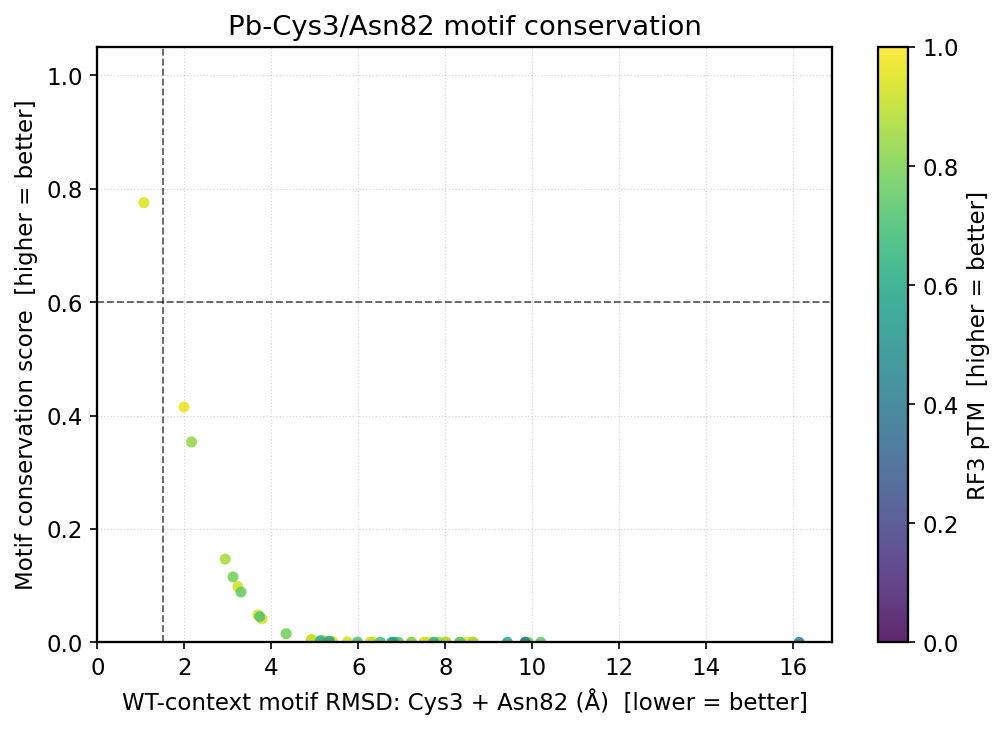

In [44]:
from pathlib import Path

# Output directory for plots from this run experiment.
PLOTS_DIR = WORK / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# -- Motif RMSD vs local conservation score, coloured by pTM --

x = df["motif4_backbone_rmsd"].to_numpy(float)
y = df["motif4_conservation_score"].to_numpy(float)
c = df["ptm"].to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    x[mask],
    y[mask],
    c=c[mask],
    s=28,
    alpha=0.85,
    linewidths=0,
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.axvline(MOTIF4_RMSD_CUT, color="k", lw=0.9, ls="--", alpha=0.6)
ax.axhline(LOCAL_SCORE_CUT, color="k", lw=0.9, ls="--", alpha=0.6)

ax.set_xlabel("WT-context motif RMSD: Cys3 + Asn82 (Å)  [lower = better]")
ax.set_ylabel("Motif conservation score  [higher = better]")
ax.set_title("Pb-Cys3/Asn82 motif conservation")

ax.set_xlim(left=0)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

fig.colorbar(sc, ax=ax).set_label("RF3 pTM  [higher = better]")

fig.tight_layout()

# Save plot before showing it.
plot_path = PLOTS_DIR / "motif4_rmsd_vs_conservation_colored_by_ptm.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {plot_path}")

plt.show()

In [ ]:
df_ranked = df.sort_values(
    [
        "passes_first_triage",
        "motif4_backbone_rmsd",
        "cys3_backbone_rmsd",
        "window_backbone_rmsd",
        "ptm",
    ],
    ascending=[False, True, True, True, False],
).copy()

OUT_RANKED = scores_dir / "rf3_wt_context_rmsd_ranked.csv"
df_ranked.to_csv(OUT_RANKED, index=False)

print("Saved:", OUT_RANKED)

df_ranked[
    [
        "design_id",
        "model_idx",
        "ptm",
        "passes_first_triage",
        "kept_cys3",
        "kept_asn82",
        "cys3_backbone_rmsd",
        "motif4_backbone_rmsd",
        "window_backbone_rmsd",
        "motif4_conservation_score",
        "window_conservation_score",
        "rf3_structure_path",
    ]
].head(3)
print

Saved: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/scores/rf3_wt_context_rmsd_ranked.csv


,design_id,model_idx,ptm,passes_first_triage,kept_cys3,kept_asn82,cys3_backbone_rmsd,motif4_backbone_rmsd,window_backbone_rmsd,motif4_conservation_score,window_conservation_score,rf3_structure_path
4,rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_...,1,0.946807,True,True,True,0.501691,1.069927,1.282976,0.775391,0.912611,/dtu/blackhole/00/222976/lead_sensoring/work/e...
0,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,2,0.965575,False,True,True,1.888930,1.989537,3.116052,0.414943,0.583079,/dtu/blackhole/00/222976/lead_sensoring/work/e...
26,rfd3_input_w6_scaffold-side-12A_5gpe_pb_motif_...,1,0.830231,False,True,True,1.837319,2.163565,4.632678,0.353375,0.303517,/dtu/blackhole/00/222976/lead_sensoring/work/e...


## 7. Collect best binders

Saved plot: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/plots/plot_01_ori_distance_vs_motif4_rmsd.png


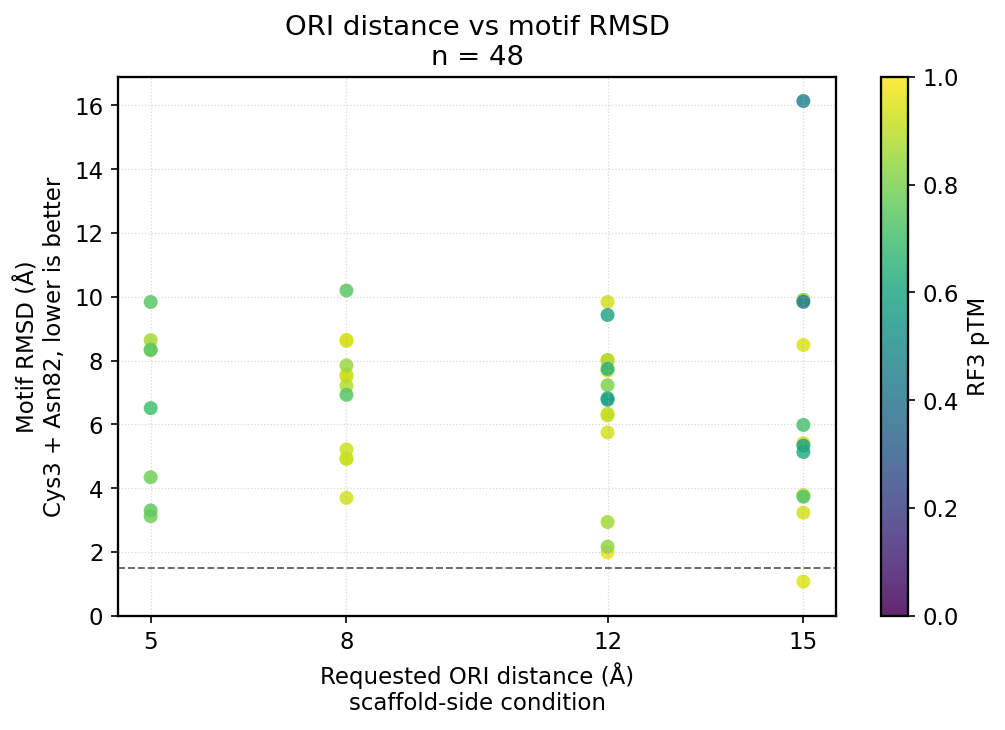

Saved plot: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/plots/plot_02_ori_distance_vs_ptm.png


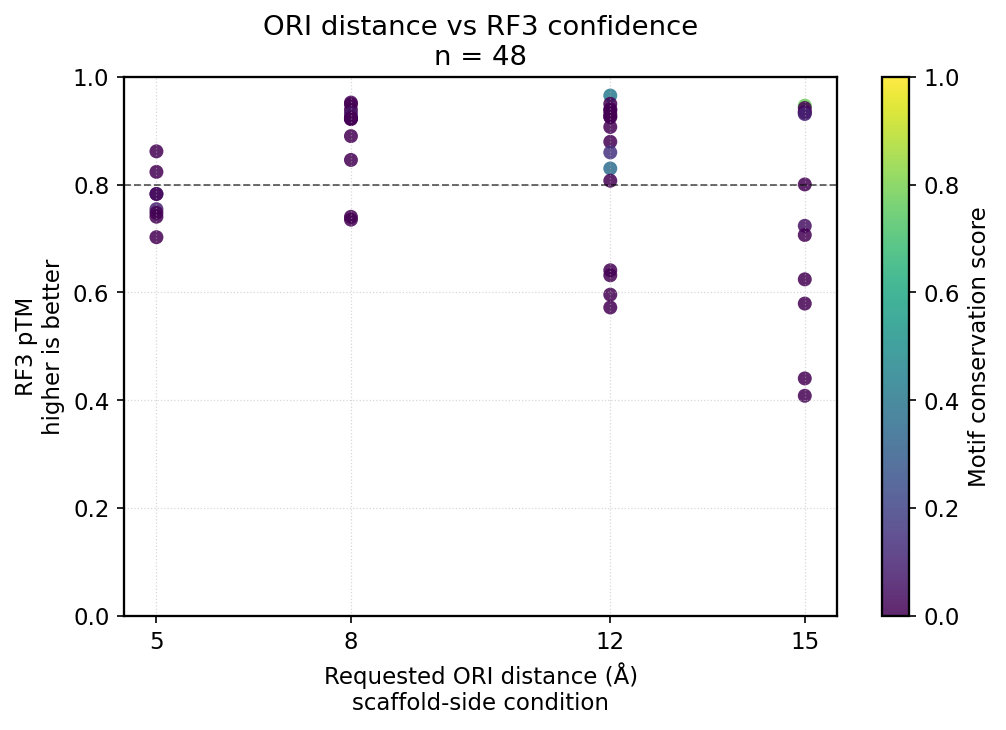

Saved plot: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/plots/plot_03_pass_rate_by_ori_distance.png


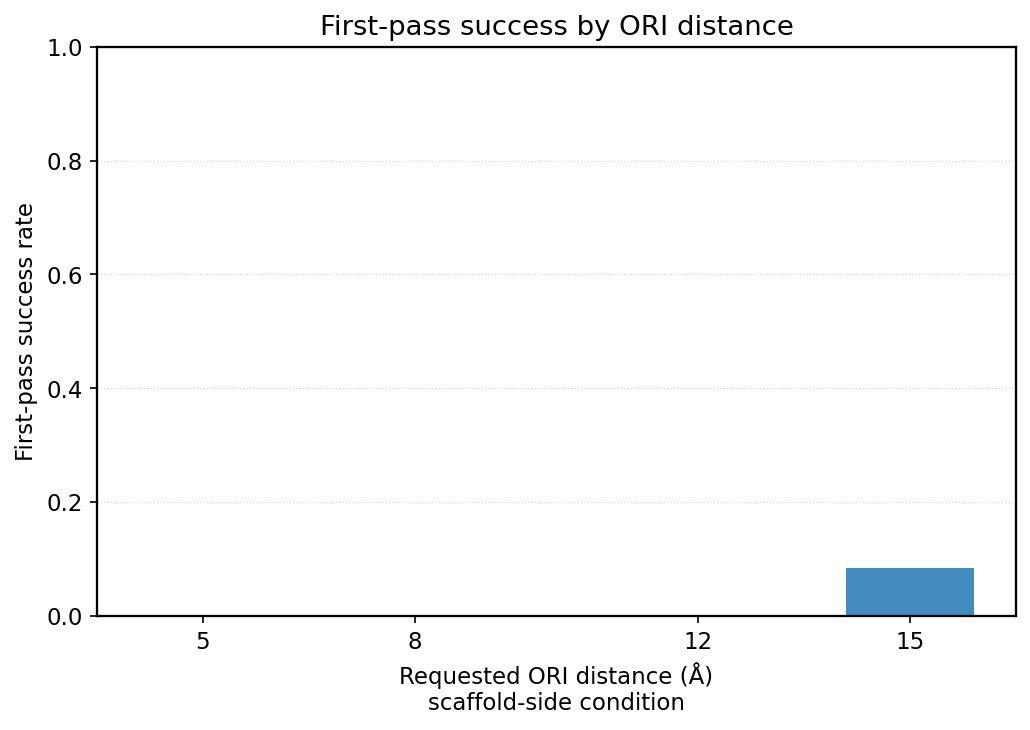

Saved plot: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/plots/plot_04_actual_com_offset_vs_motif4_rmsd.png


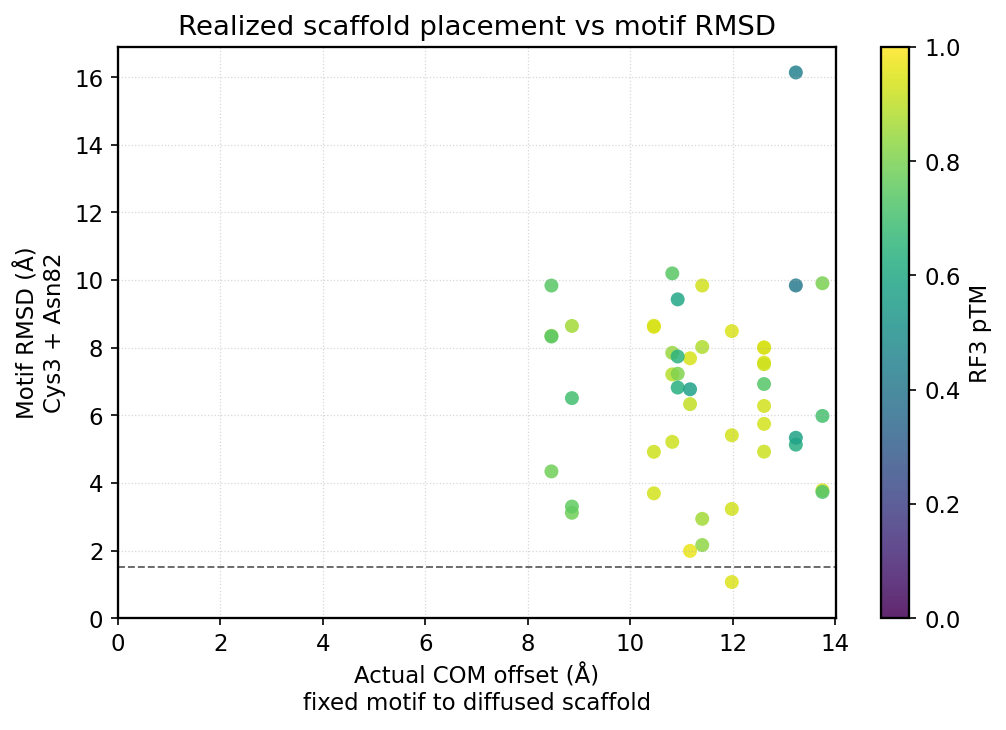

Saved plot: /dtu/blackhole/00/222976/lead_sensoring/work/exp_01_rfd3_mpnn_rf3/plots/plot_05_rf3_validation_two_panel.png


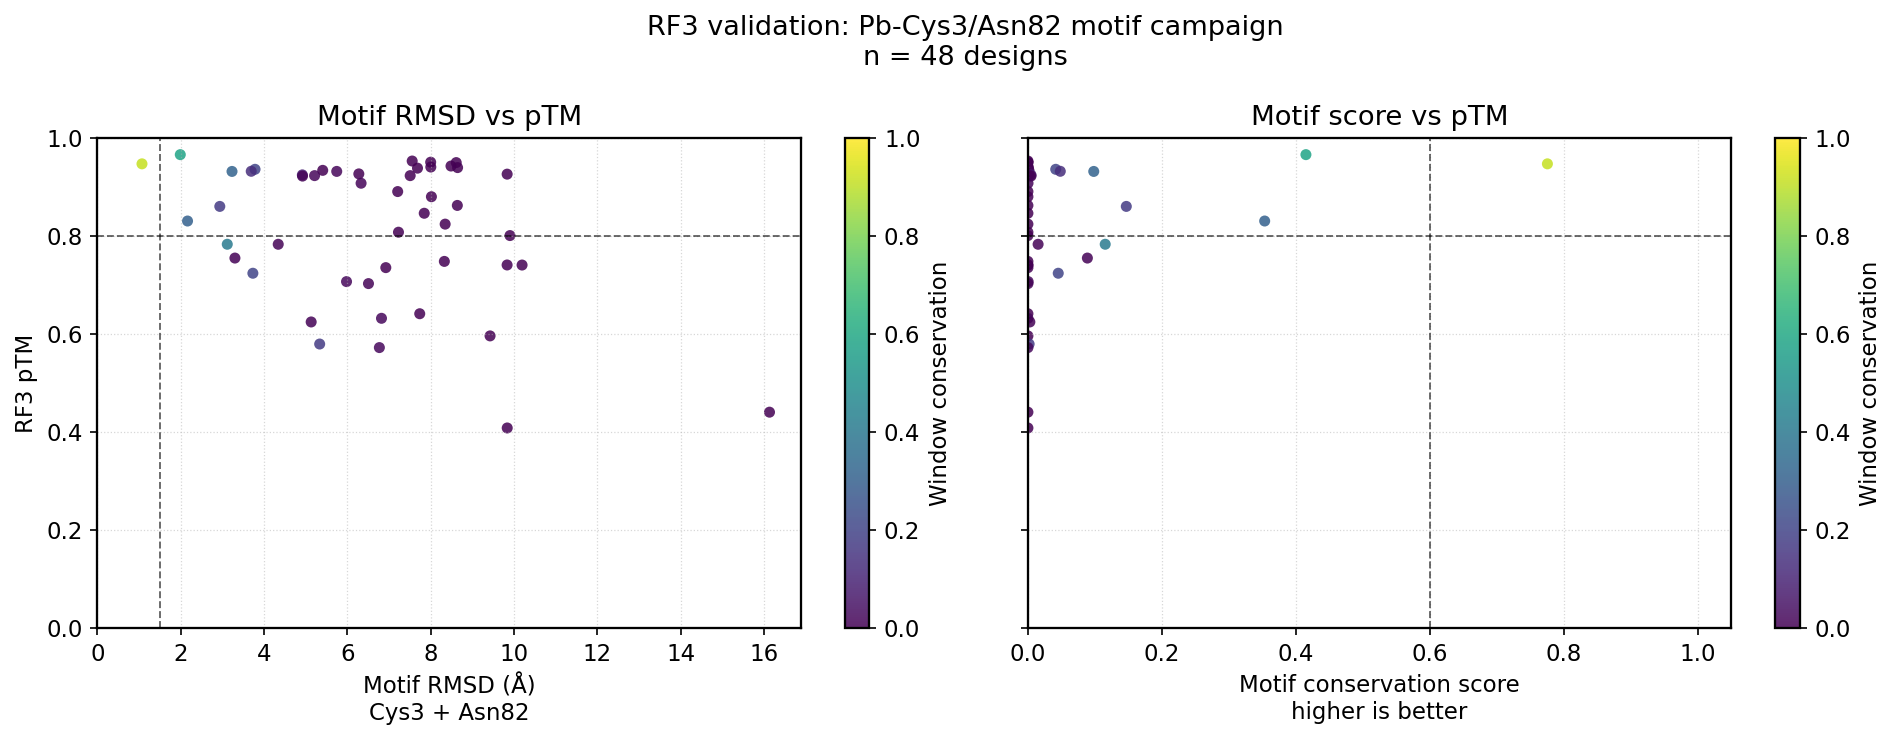

In [45]:
# -----------------------------
# Plot settings
# -----------------------------

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.linewidth": 1.1,
    "figure.dpi": 150,
})

plots_dir = WORK / "plots"

plots_dir.mkdir(parents=True, exist_ok=True)

def save_plot(fig, filename, dpi=300):
    """
    Save a matplotlib figure as PNG inside the run-level plots directory.
    """
    out_path = plots_dir / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved plot: {out_path}")


df = df_plot.copy()
xticks = sorted(df["requested_ori_A"].dropna().unique())

# ============================================================
# Plot 1: ORI distance vs motif RMSD
# ============================================================

x = df["requested_ori_A"].to_numpy(float)
y = df["motif4_backbone_rmsd"].to_numpy(float)
c = df["ptm"].to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    x[mask],
    y[mask],
    c=c[mask],
    s=45,
    alpha=0.85,
    linewidths=0,
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.axhline(MOTIF4_RMSD_CUT, color="k", lw=0.9, ls="--", alpha=0.6)

ax.set_xlabel("Requested ORI distance (Å)\nscaffold-side condition")
ax.set_ylabel("Motif RMSD (Å)\nCys3 + Asn82, lower is better")
ax.set_title(f"ORI distance vs motif RMSD\nn = {len(df)}")

ax.set_xticks(xticks)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

fig.colorbar(sc, ax=ax).set_label("RF3 pTM")

fig.tight_layout()
save_plot(fig, "plot_01_ori_distance_vs_motif4_rmsd.png")
plt.show()

# ============================================================
# Plot 2: ORI distance vs pTM
# ============================================================

x = df["requested_ori_A"].to_numpy(float)
y = df["ptm"].to_numpy(float)
c = df["motif4_conservation_score"].to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    x[mask],
    y[mask],
    c=c[mask],
    s=45,
    alpha=0.85,
    linewidths=0,
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.axhline(PTM_CUT, color="k", lw=0.9, ls="--", alpha=0.6)

ax.set_xlabel("Requested ORI distance (Å)\nscaffold-side condition")
ax.set_ylabel("RF3 pTM\nhigher is better")
ax.set_title(f"ORI distance vs RF3 confidence\nn = {len(df)}")

ax.set_xticks(xticks)
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

fig.colorbar(sc, ax=ax).set_label("Motif conservation score")

fig.tight_layout()
save_plot(fig, "plot_02_ori_distance_vs_ptm.png")
plt.show()

# ============================================================
# Plot 3: Pass rate by ORI distance
# ============================================================

summary_clean = summary_by_ori.dropna(subset=["requested_ori_A"]).copy()

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    summary_clean["requested_ori_A"],
    summary_clean["pass_rate"],
    width=1.8,
    alpha=0.85,
)

ax.set_xlabel("Requested ORI distance (Å)\nscaffold-side condition")
ax.set_ylabel("First-pass success rate")
ax.set_title("First-pass success by ORI distance")

ax.set_xticks(summary_clean["requested_ori_A"])
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y", linestyle=":", linewidth=0.6, alpha=0.5)

fig.tight_layout()
save_plot(fig, "plot_03_pass_rate_by_ori_distance.png")
plt.show()

# ============================================================
# Plot 4: Actual COM offset vs motif RMSD
# ============================================================

x = df["actual_fixed_to_diffused_com_A"].to_numpy(float)
y = df["motif4_backbone_rmsd"].to_numpy(float)
c = df["ptm"].to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    x[mask],
    y[mask],
    c=c[mask],
    s=45,
    alpha=0.85,
    linewidths=0,
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.axhline(MOTIF4_RMSD_CUT, color="k", lw=0.9, ls="--", alpha=0.6)

ax.set_xlabel("Actual COM offset (Å)\nfixed motif to diffused scaffold")
ax.set_ylabel("Motif RMSD (Å)\nCys3 + Asn82")
ax.set_title("Realized scaffold placement vs motif RMSD")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

fig.colorbar(sc, ax=ax).set_label("RF3 pTM")

fig.tight_layout()
save_plot(fig, "plot_04_actual_com_offset_vs_motif4_rmsd.png")
plt.show()

# ============================================================
# Plot 5: two-panel RF3 validation
# ============================================================

x_rmsd = df["motif4_backbone_rmsd"].to_numpy(float)
x_score = df["motif4_conservation_score"].to_numpy(float)
y_ptm = df["ptm"].to_numpy(float)
c_window = df["window_conservation_score"].to_numpy(float)

mask = (
    np.isfinite(x_rmsd)
    & np.isfinite(x_score)
    & np.isfinite(y_ptm)
    & np.isfinite(c_window)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

sc0 = axes[0].scatter(
    x_rmsd[mask],
    y_ptm[mask],
    c=c_window[mask],
    s=28,
    alpha=0.85,
    linewidths=0,
    cmap="viridis",
    vmin=0,
    vmax=1,
)

axes[0].axvline(MOTIF4_RMSD_CUT, color="k", lw=0.9, ls="--", alpha=0.6)
axes[0].axhline(PTM_CUT, color="k", lw=0.9, ls="--", alpha=0.6)
axes[0].set_xlabel("Motif RMSD (Å)\nCys3 + Asn82")
axes[0].set_ylabel("RF3 pTM")
axes[0].set_title("Motif RMSD vs pTM")
axes[0].set_xlim(left=0)
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

fig.colorbar(sc0, ax=axes[0]).set_label("Window conservation")

sc1 = axes[1].scatter(
    x_score[mask],
    y_ptm[mask],
    c=c_window[mask],
    s=28,
    alpha=0.85,
    linewidths=0,
    cmap="viridis",
    vmin=0,
    vmax=1,
)

axes[1].axvline(LOCAL_SCORE_CUT, color="k", lw=0.9, ls="--", alpha=0.6)
axes[1].axhline(PTM_CUT, color="k", lw=0.9, ls="--", alpha=0.6)
axes[1].set_xlabel("Motif conservation score\nhigher is better")
axes[1].set_title("Motif score vs pTM")
axes[1].set_xlim(0, 1.05)
axes[1].grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

fig.colorbar(sc1, ax=axes[1]).set_label("Window conservation")

fig.suptitle(
    f"RF3 validation: Pb-Cys3/Asn82 motif campaign\nn = {len(df)} designs",
    fontsize=13,
)

fig.tight_layout()
save_plot(fig, "plot_05_rf3_validation_two_panel.png")
plt.show()